# 34MLS Assignment 3 - Predicting Flow in Porous Medium 
Michaela Ivanova 
1685112 

Note! For the pdf version of the notebook, the cell outputs have been colapsed, since it would be around 500 pages then. This also means the plots of the loss are lost, but the most important ones are in the report, and the secondary ones should still be visible in the .ipynb version.

## HOMOGENEOUS CLEAN NO AUGMENTATIONS

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import random 
import torch.backends.cudnn as cudnn

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 33
Layer-wise parameter count:
cnn.0.weight                   | 144
cnn.0.bias                     | 16
cnn.2.weight                   | 4608
cnn.2.bias                     | 32
cnn.4.weight                   | 18432
cnn.4.bias                     | 64
cnn.6.weight                   | 18432
cnn.6.bias                     | 32
cnn.8.weight                   | 32
cnn.8.bias                     | 1

 Total trainable parameters: 41,793


Epoch 1/200: 100%|██████████| 43/43 [00:00<00:00, 87.40it/s]



Epoch 1 — Train Loss: 3281.121382
Epoch 1 — Val Loss: 975.810742
Training complete.


Epoch 2/200: 100%|██████████| 43/43 [00:00<00:00, 274.18it/s]


...


Epoch 126 — Train Loss: 5.626722
Epoch 126 — Val Loss: 5.101169
Training complete.


Epoch 127/200: 100%|██████████| 43/43 [00:00<00:00, 270.45it/s]



Epoch 127 — Train Loss: 5.608418
Epoch 127 — Val Loss: 5.102302
Training complete.


Epoch 128/200: 100%|██████████| 43/43 [00:00<00:00, 270.88it/s]



Epoch 128 — Train Loss: 5.638117
Epoch 128 — Val Loss: 5.105096
Early stopping triggered.


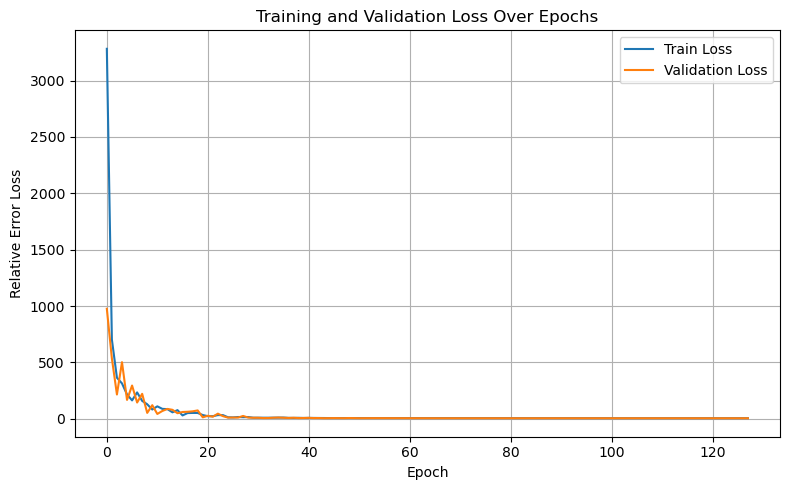

Training metrics saved to 'training_metrics.csv'


In [ ]:
def set_seed(seed):         #CHANGING THE SEED IS HELPING! 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")
    
# -------------------- Dataset Class --------------------
class PorousFlowHomogeneousDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.scalars = (params_df['delta_p'] * params_df['delta_A']) / (params_df['visc'] * params_df['L'])
        self.scalars = self.scalars.values.astype(np.float32).reshape(-1, 1)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid = self.binary_grids[idx]  
        scalar = self.scalars[idx]     
        
        # Multiply grid by scalar — only 1's are affected!
        scaled_grid = grid * scalar  
        grid_tensor = torch.tensor(scaled_grid).unsqueeze(0)  
        
        label = torch.tensor(self.flow_fields[idx])  

        if self.transform:
            grid_tensor = self.transform(grid_tensor)

        return grid_tensor, label

# -------------------- Model Definition --------------------
class HomogeneousFlowCNN(nn.Module):
    def __init__(self):
        super(HomogeneousFlowCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1)
        )

    def forward(self, x):
        out = self.cnn(x)
        return out.squeeze(1)

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10


    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model_homogeneous_1_newest.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

        print("Training complete.")

 
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_1_newwest.png")
    plt.show()

   
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_1_newest.csv", index=False)
    print("Training metrics saved to 'training_metrics.csv'")

    return model


def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading + Training --------------------
# Device selection
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load data
binary_grids = np.load("train_inputs.npy")
flow_fields = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

# Dataset and split
dataset = PorousFlowHomogeneousDataset(binary_grids, params_df, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


set_seed(33)  # You can choose any seed number
# Train
model = HomogeneousFlowCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=200, lr=5e-4, device=device)


## HOMOGENEOUS WITH AUGMENTATIONS

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 33
Layer-wise parameter count:
cnn.0.weight                   | 144
cnn.0.bias                     | 16
cnn.2.weight                   | 4608
cnn.2.bias                     | 32
cnn.4.weight                   | 18432
cnn.4.bias                     | 64
cnn.6.weight                   | 18432
cnn.6.bias                     | 32
cnn.8.weight                   | 32
cnn.8.bias                     | 1

 Total trainable parameters: 41,793


Epoch 1/200: 100%|██████████| 169/169 [00:00<00:00, 184.43it/s]



Epoch 1 — Train Loss: 1179.677261
Epoch 1 — Val Loss: 227.184892
Training complete.


Epoch 2/200: 100%|██████████| 169/169 [00:00<00:00, 264.01it/s]


...


Epoch 80 — Train Loss: 0.716071
Epoch 80 — Val Loss: 0.650138
Training complete.


Epoch 81/200: 100%|██████████| 169/169 [00:00<00:00, 265.19it/s]



Epoch 81 — Train Loss: 0.636715
Epoch 81 — Val Loss: 0.698994
Training complete.


Epoch 82/200: 100%|██████████| 169/169 [00:00<00:00, 269.11it/s]



Epoch 82 — Train Loss: 0.637810
Epoch 82 — Val Loss: 0.690025
Early stopping triggered.


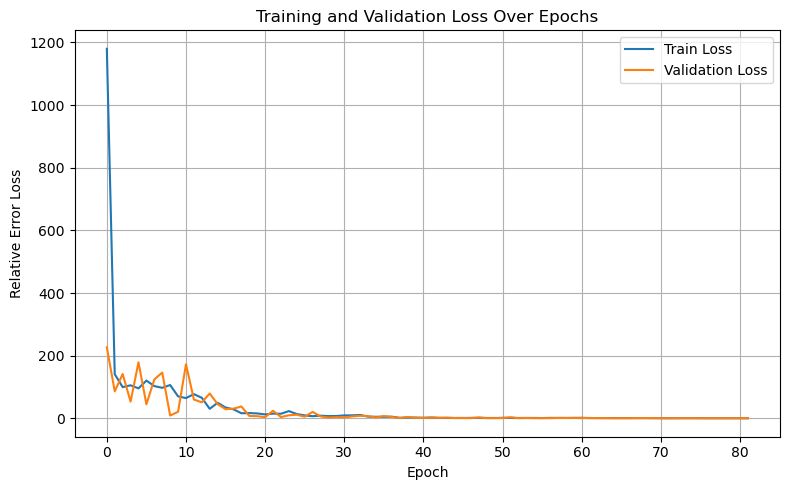

Training metrics saved to 'training_metrics.csv'


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

def apply_symmetry_augmentations(grid, scalar, label):
    """
    Applies flips: original, horizontal, vertical, and both.
    Returns a list of (grid, scalar, label) tuples.
    """
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid, label
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)
        augmented.append((g.copy(), scalar.copy(), l.copy()))
    return augmented


# -------------------- Dataset Class --------------------
class PorousFlowHomogeneousDataset(Dataset):
    def __init__(self, binary_grids, scalars, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.scalars = scalars.astype(np.float32).reshape(-1, 1)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid = self.binary_grids[idx]
        scalar = self.scalars[idx]

        # Multiply grid by scalar to scale 1s and keep 0s unchanged!
        scaled_grid = grid * scalar
        grid_tensor = torch.tensor(scaled_grid).unsqueeze(0)  
        label = torch.tensor(self.flow_fields[idx])           

        if self.transform:
            grid_tensor = self.transform(grid_tensor)

        return grid_tensor, label


# -------------------- Model Definition --------------------
class HomogeneousFlowCNN(nn.Module):
    def __init__(self):
        super(HomogeneousFlowCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1)
        )

    def forward(self, x):
        out = self.cnn(x)
        return out.squeeze(1)


# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)


# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model_scaled_input.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

        print("Training complete.")
    
 


    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_1.png")
    plt.show()

    # to save metrics just in case
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_1.csv", index=False)
    print("Training metrics saved to 'training_metrics.csv'")

    return model


def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading and  Training --------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'
binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

augmented_grids = []
augmented_scalars = []
augmented_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]

   
    scalar = (params_df['delta_p'].iloc[i] * params_df['delta_A'].iloc[i]) / (
              params_df['visc'].iloc[i] * params_df['L'].iloc[i])

    augmented = apply_symmetry_augmentations(grid, scalar, label)
    for g, s, l in augmented:
        augmented_grids.append(g)
        augmented_scalars.append(s)
        augmented_labels.append(l)


binary_grids = np.array(augmented_grids)
scalars = np.array(augmented_scalars).reshape(-1, 1)
flow_fields = np.array(augmented_labels)


# Data and split
dataset = PorousFlowHomogeneousDataset(binary_grids, scalars, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


set_seed(33)  

# train
model = HomogeneousFlowCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=200, lr=5e-4, device=device)


## HOMOGENEOUS WITH DISAMBIGUATING THE SYMMETRY

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 33
Layer-wise parameter count:
cnn.0.weight                   | 144
cnn.0.bias                     | 16
cnn.2.weight                   | 4608
cnn.2.bias                     | 32
cnn.4.weight                   | 18432
cnn.4.bias                     | 64
cnn.6.weight                   | 18432
cnn.6.bias                     | 32
cnn.8.weight                   | 32
cnn.8.bias                     | 1

🔢 Total trainable parameters: 41,793


Epoch 1/200: 100%|██████████| 43/43 [00:00<00:00, 93.78it/s] 



Epoch 1 — Train Loss: 4069.213734
Epoch 1 — Val Loss: 864.163794
Training complete.


Epoch 2/200: 100%|██████████| 43/43 [00:00<00:00, 274.18it/s]


...


Epoch 112 — Train Loss: 2.556367
Epoch 112 — Val Loss: 2.616269
Training complete.


Epoch 113/200: 100%|██████████| 43/43 [00:00<00:00, 259.64it/s]



Epoch 113 — Train Loss: 2.576468
Epoch 113 — Val Loss: 2.611720
Training complete.


Epoch 114/200: 100%|██████████| 43/43 [00:00<00:00, 277.32it/s]



Epoch 114 — Train Loss: 2.593329
Epoch 114 — Val Loss: 2.635532
Early stopping triggered.


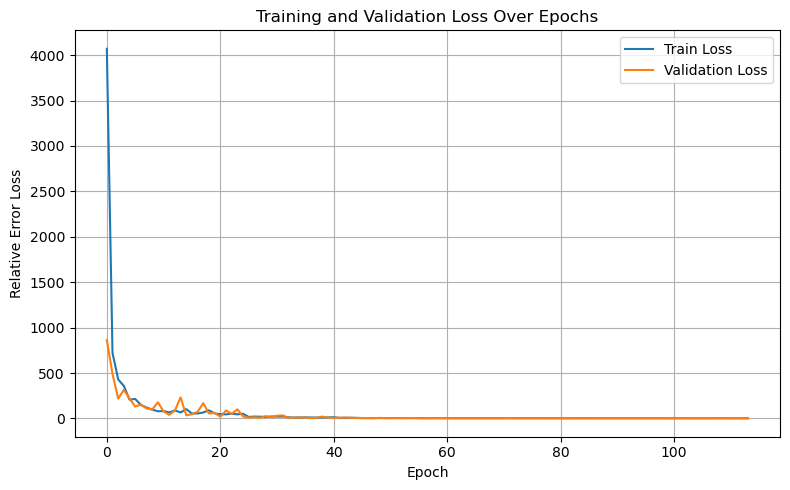

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Best Symmetry Selection --------------------
def select_best_symmetry_configuration(grid, scalar, label):
    best_score = -1
    best_config = None

    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()

        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)

        # bottom-left quadrant
        h, w = g.shape
        bl_quadrant = g[h//2:, :w//2]
        score = np.sum(bl_quadrant == 1)

        if score > best_score:
            best_score = score
            g_scaled = g * scalar  
            best_config = (g_scaled.copy(), l.copy())

    return best_config

# -------------------- Dataset  --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, scaled_grids, flow_fields, transform=None):
        self.scaled_grids = scaled_grids.astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])              
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- Model Definition --------------------
class HomogeneousFlowCNN(nn.Module):
    def __init__(self):
        super(HomogeneousFlowCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.cnn(x).squeeze(1)

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        return torch.mean(torch.abs(pred - target) / (target + self.eps))

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model_disambiguating.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

        print("Training complete.")

    # Plot loss
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_best_disambiguating.png")
    plt.show()

    # Save to CSV
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_best_disambiguating.csv", index=False)

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n🔢 Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading and Training --------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load raw data
binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

# Apply best symmetry selection and scale
scaled_grids = []
flow_fields = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]
    scalar = (params_df['delta_p'][i] * params_df['delta_A'][i]) / (params_df['visc'][i] * params_df['L'][i])
    g_scaled, l_best = select_best_symmetry_configuration(grid, scalar, label)
    scaled_grids.append(g_scaled)
    flow_fields.append(l_best)

scaled_grids = np.array(scaled_grids)
flow_fields = np.array(flow_fields)

# Data and split
dataset = ScaledGridDataset(scaled_grids, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(33)

# Train
model = HomogeneousFlowCNN()
trained_model = train_model(model, train_loader, val_loader, num_epochs=200, lr=5e-4, device=device)


## DIMENSIONLESS CLEAN NO AUGMENTATIONS

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 36
Layer-wise parameter count:
cnn.0.weight                   | 144
cnn.0.bias                     | 16
cnn.2.weight                   | 4608
cnn.2.bias                     | 32
cnn.4.weight                   | 18432
cnn.4.bias                     | 64
cnn.6.weight                   | 64
cnn.6.bias                     | 1

 Total trainable parameters: 23,361


Epoch 1/500: 100%|██████████| 43/43 [00:00<00:00, 97.48it/s] 



Epoch 1 — Train Loss: 3845.429656
Epoch 1 — Val Loss: 1573.876807


Epoch 2/500: 100%|██████████| 43/43 [00:00<00:00, 368.55it/s]


...


Epoch 139 — Train Loss: 39.972223
Epoch 139 — Val Loss: 38.781654


Epoch 140/500: 100%|██████████| 43/43 [00:00<00:00, 319.31it/s]



Epoch 140 — Train Loss: 40.149981
Epoch 140 — Val Loss: 38.779530


Epoch 141/500: 100%|██████████| 43/43 [00:00<00:00, 375.81it/s]



Epoch 141 — Train Loss: 39.803039
Epoch 141 — Val Loss: 38.759688
Early stopping triggered.
Training complete.


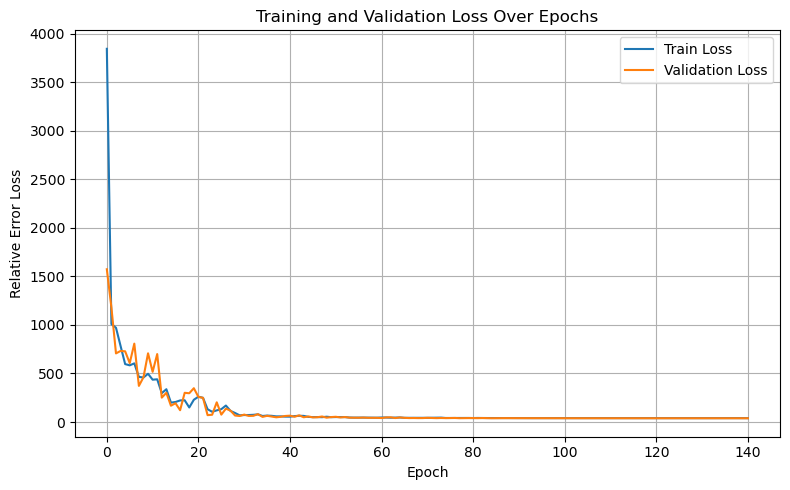

 Training metrics saved.


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")
    
# -------------------- Dataset Class --------------------
class PorousFlowDimensionlessDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)

        
        mu = params_df['visc'].values
        L = params_df['L'].values
        delta_p = params_df['delta_p'].values
        delta_A = params_df['delta_A'].values

        self.scales = (mu * L) / (delta_p * delta_A)  
        self.scales = self.scales.astype(np.float32).reshape(-1, 1, 1)

        # dimensionless targets
        self.flow_fields = flow_fields.astype(np.float32) * self.scales
        self.binary_grids = binary_grids.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.binary_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])               

        if self.transform:
            grid_tensor = self.transform(grid_tensor)

        return grid_tensor, label_tensor


# -------------------- Model Definition --------------------
class DimensionlessFlowCNN(nn.Module):
    def __init__(self):
        super(DimensionlessFlowCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        out = self.cnn(x)           
        return out.squeeze(1)       

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model_dimensionless1.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_dimensionless1.png")
    plt.show()

    # save metrics
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_dimensionless1.csv", index=False)
    print(" Training metrics saved.")

    return model

# -------------------- Parameter Counter --------------------
def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params


device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load data
binary_grids = np.load("train_inputs.npy")
flow_fields = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

# build the datase 
dataset = PorousFlowDimensionlessDataset(binary_grids, params_df, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(36)

# Train model
model = DimensionlessFlowCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=500, lr=5e-4, device=device)

## DIMENSIONLESS AUGMENTATIONS

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 69
Layer-wise parameter count:
cnn.0.weight                   | 144
cnn.0.bias                     | 16
cnn.2.weight                   | 4608
cnn.2.bias                     | 32
cnn.4.weight                   | 18432
cnn.4.bias                     | 64
cnn.6.weight                   | 64
cnn.6.bias                     | 1

 Total trainable parameters: 23,361


Epoch 1/500: 100%|██████████| 169/169 [00:00<00:00, 257.83it/s]



Epoch 1 — Train Loss: 894.150110
Epoch 1 — Val Loss: 404.040132


Epoch 2/500: 100%|██████████| 169/169 [00:00<00:00, 368.96it/s]


...


Epoch 102 — Train Loss: 0.723818
Epoch 102 — Val Loss: 0.685265


Epoch 103/500: 100%|██████████| 169/169 [00:00<00:00, 370.07it/s]



Epoch 103 — Train Loss: 0.709685
Epoch 103 — Val Loss: 0.721147


Epoch 104/500: 100%|██████████| 169/169 [00:00<00:00, 401.37it/s]



Epoch 104 — Train Loss: 0.708814
Epoch 104 — Val Loss: 0.715353
Early stopping triggered.
Training complete.


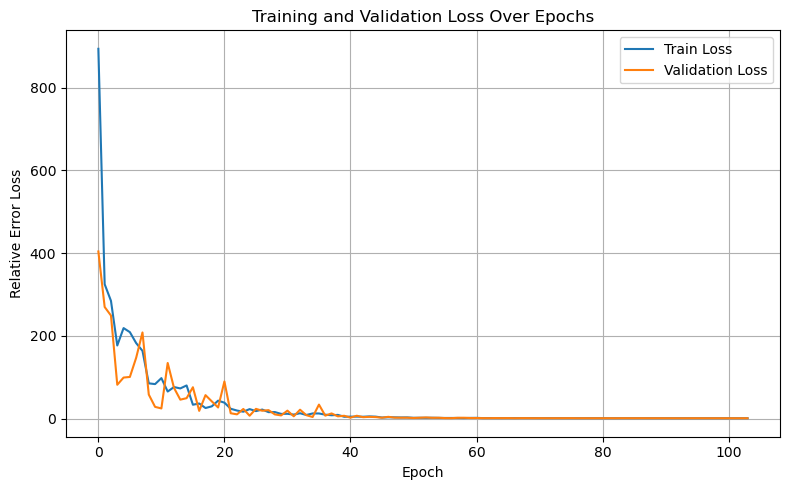

 Training metrics saved.


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")
    

def apply_symmetry_augmentations(grid, label):
 
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)
        augmented.append((g, l))
    return augmented


# -------------------- Dataset Class --------------------
class PorousFlowDimensionlessDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)

        mu = params_df['visc'].values
        L = params_df['L'].values
        delta_p = params_df['delta_p'].values
        delta_A = params_df['delta_A'].values

        self.scales = (mu * L) / (delta_p * delta_A) 
        self.scales = self.scales.astype(np.float32).reshape(-1, 1, 1)

        #dimensionless targets
        self.flow_fields = flow_fields.astype(np.float32) * self.scales
        self.binary_grids = binary_grids.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.binary_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])               

        if self.transform:
            grid_tensor = self.transform(grid_tensor)

        return grid_tensor, label_tensor


# -------------------- Model Definition --------------------
class DimensionlessFlowCNN(nn.Module):
    def __init__(self):
        super(DimensionlessFlowCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        out = self.cnn(x)           
        return out.squeeze(1)       

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model_dimensionless_1.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_dimensionless_1.png")
    plt.show()

   
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_dimensionless_1.csv", index=False)
    print(" Training metrics saved.")

    return model

# -------------------- Parameter Counter --------------------
def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params


device = 'cuda' if torch.cuda.is_available() else 'cpu'


binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")


mu = params_df['visc'].values
L = params_df['L'].values
delta_p = params_df['delta_p'].values
delta_A = params_df['delta_A'].values
scales = ((mu * L) / (delta_p * delta_A)).astype(np.float32).reshape(-1, 1, 1)

# augmentations
augmented_grids = []
augmented_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i] * scales[i]  # dimensionless! 
    
    augmented = apply_symmetry_augmentations(grid, label)
    for g_aug, l_aug in augmented:
        augmented_grids.append(g_aug)
        augmented_labels.append(l_aug)


binary_grids = np.array(augmented_grids)
flow_fields = np.array(augmented_labels)

dataset = PorousFlowDimensionlessDataset(binary_grids, params_df.iloc[:len(binary_grids_raw)].loc[np.repeat(range(len(binary_grids_raw)), 4)].reset_index(drop=True), flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(69)

# Train model
model = DimensionlessFlowCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=500, lr=5e-4, device=device)

## DIMENSIONLESS DISAMBIGUATING THE SYMMETRY

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 69
Layer-wise parameter count:
cnn.0.weight                   | 144
cnn.0.bias                     | 16
cnn.2.weight                   | 4608
cnn.2.bias                     | 32
cnn.4.weight                   | 18432
cnn.4.bias                     | 64
cnn.6.weight                   | 64
cnn.6.bias                     | 1

 Total trainable parameters: 23,361


Epoch 1/200: 100%|██████████| 43/43 [00:00<00:00, 86.84it/s]



Epoch 1 — Train Loss: 2244.472445
Epoch 1 — Val Loss: 699.312158


Epoch 2/200: 100%|██████████| 43/43 [00:00<00:00, 360.97it/s]


...


Epoch 158 — Train Loss: 15.259197
Epoch 158 — Val Loss: 15.455628


Epoch 159/200: 100%|██████████| 43/43 [00:00<00:00, 379.44it/s]



Epoch 159 — Train Loss: 15.313184
Epoch 159 — Val Loss: 15.445143


Epoch 160/200: 100%|██████████| 43/43 [00:00<00:00, 359.12it/s]



Epoch 160 — Train Loss: 15.256832
Epoch 160 — Val Loss: 15.441226
Early stopping triggered.
Training complete.


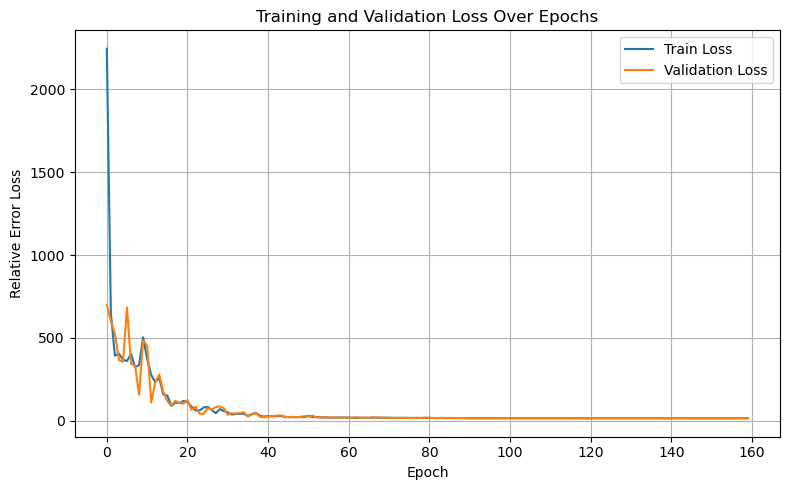

 Training metrics saved.


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

def select_best_symmetry_configuration(grid, label, scale):
  
    best_score = -1
    best_config = None

    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()

        # Apply flip
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)

        # Evaluate bottom-left quadrant
        h, w = g.shape
        bl_quadrant = g[h//2:, :w//2]
        score = np.sum(bl_quadrant == 1)

        # Store best
        if score > best_score:
            best_score = score
            best_config = (g.copy(), l.copy())

    return best_config


# -------------------- Dataset Class --------------------
class PorousFlowDimensionlessDataset(Dataset):
    def __init__(self, binary_grids, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.binary_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])               

        if self.transform:
            grid_tensor = self.transform(grid_tensor)

        return grid_tensor, label_tensor


# -------------------- Model Definition --------------------
class DimensionlessFlowCNN(nn.Module):
    def __init__(self):
        super(DimensionlessFlowCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        out = self.cnn(x)           
        return out.squeeze(1)       

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model_dimensionless_disamb_cnn.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_dimensionless_disamb_cnn.png")
    plt.show()

   
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_dimensionless_disamb_cnn.csv", index=False)
    print(" Training metrics saved.")

    return model

# -------------------- Parameter Counter --------------------
def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params


device = 'cuda' if torch.cuda.is_available() else 'cpu'


binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

# scaling
mu = params_df['visc'].values
L = params_df['L'].values
delta_p = params_df['delta_p'].values
delta_A = params_df['delta_A'].values
scales = ((mu * L) / (delta_p * delta_A)).astype(np.float32).reshape(-1, 1, 1)

# disambiguation 
disambiguated_grids = []
disambiguated_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    # Scale dimensionless
    label = flow_fields_raw[i] * scales[i]  
    
    # Select best configuration
    best_grid, best_label = select_best_symmetry_configuration(grid, label, scales[i])
    disambiguated_grids.append(best_grid)
    disambiguated_labels.append(best_label)

binary_grids = np.array(disambiguated_grids)
flow_fields = np.array(disambiguated_labels)

dataset = PorousFlowDimensionlessDataset(binary_grids, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(69)

# Train model
model = DimensionlessFlowCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=200, lr=5e-4, device=device)

## VGG HOMOGENEOUS NO AUGMENTATIONS

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 33
Layer-wise parameter count:
features.0.weight              | 288
features.0.bias                | 32
features.2.weight              | 9216
features.2.bias                | 32
features.4.weight              | 18432
features.4.bias                | 64
features.6.weight              | 36864
features.6.bias                | 64
features.8.weight              | 73728
features.8.bias                | 128
features.10.weight             | 147456
features.10.bias               | 128
features.12.weight             | 73728
features.12.bias               | 64
features.14.weight             | 64
features.14.bias               | 1

 Total trainable parameters: 360,289


Epoch 1/500: 100%|██████████| 43/43 [00:01<00:00, 28.40it/s]



Epoch 1 — Train Loss: 2391.977402
Epoch 1 — Val Loss: 208.148709


Epoch 2/500: 100%|██████████| 43/43 [00:01<00:00, 41.42it/s]


...


Epoch 84 — Train Loss: 1.842457
Epoch 84 — Val Loss: 1.946418


Epoch 85/500: 100%|██████████| 43/43 [00:01<00:00, 40.60it/s]



Epoch 85 — Train Loss: 1.853914
Epoch 85 — Val Loss: 1.930514


Epoch 86/500: 100%|██████████| 43/43 [00:01<00:00, 41.11it/s]



Epoch 86 — Train Loss: 1.836411
Epoch 86 — Val Loss: 1.923197
Early stopping triggered.


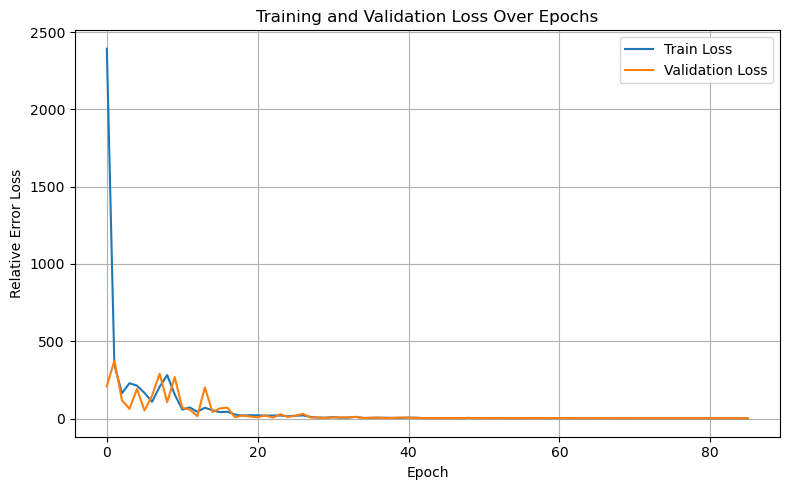

 Training metrics saved to 'training_metrics_vgg_scaled.csv'


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Dataset Class --------------------
class ScaledGridVGGDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.scalars = (params_df['delta_p'] * params_df['delta_A']) / (params_df['visc'] * params_df['L'])
        self.scalars = self.scalars.values.astype(np.float32).reshape(-1, 1)
        self.scaled_grids = (binary_grids.astype(np.float32) * self.scalars.reshape(-1, 1, 1)).astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])              
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- VGG-Style CNN --------------------
class VGGStyleHomogeneousCNN(nn.Module):
    def __init__(self):
        super(VGGStyleHomogeneousCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.features(x).squeeze(1)  

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        return torch.mean(numerator / denominator)

# -------------------- Evaluation --------------------
def evaluate_model(model, loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in loader:
            grid_batch, target_batch = grid_batch.to(device), target_batch.to(device)
            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch, target_batch = grid_batch.to(device), target_batch.to(device)
            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                early_stop_counter = 0
                torch.save(model.state_dict(), 'best_model_vgg_scaled.pth')
            else:
                early_stop_counter += 1
            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_vgg_scaled.png")
    plt.show()

  
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_vgg_scaled.csv", index=False)
    print(" Training metrics saved to 'training_metrics_vgg_scaled.csv'")
    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Load Data + Run Training --------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
binary_grids = np.load("train_inputs.npy")
flow_fields = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

# Dataset
dataset = ScaledGridVGGDataset(binary_grids, params_df, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

set_seed()

# Train
model = VGGStyleHomogeneousCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=500, lr=5e-4, device=device)


## VGG HOMOGENEOUS AUGMENTATIONS

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 36

 Total trainable parameters: 360,289


Epoch 1/500: 100%|██████████| 85/85 [00:03<00:00, 24.72it/s]



Epoch 1 — Train Loss: 1382.029624
Epoch 1 — Val Loss: 338.919894


Epoch 2/500: 100%|██████████| 85/85 [00:03<00:00, 27.59it/s]


...


Epoch 135 — Train Loss: 1.479557
Epoch 135 — Val Loss: 1.592891


Epoch 136/500: 100%|██████████| 85/85 [00:03<00:00, 27.46it/s]



Epoch 136 — Train Loss: 1.487417
Epoch 136 — Val Loss: 1.583942


Epoch 137/500: 100%|██████████| 85/85 [00:03<00:00, 27.39it/s]



Epoch 137 — Train Loss: 1.488441
Epoch 137 — Val Loss: 1.603415
Early stopping triggered.


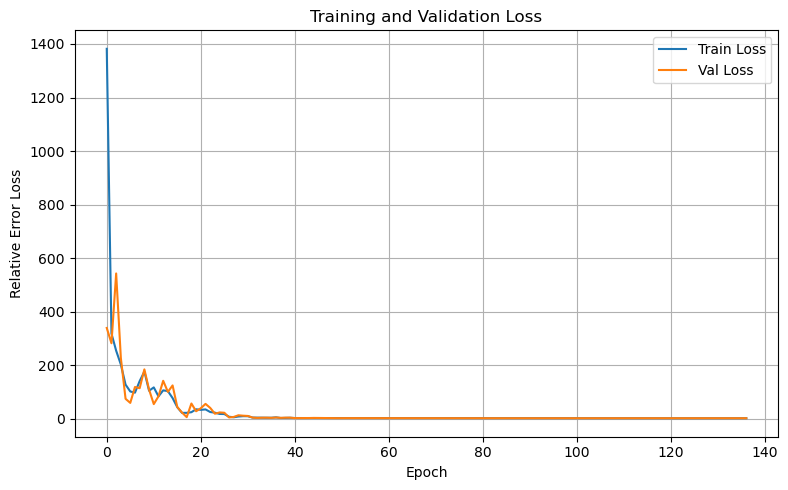

 Metrics saved to 'training_metrics_vgg_scaled_augmented.csv'


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Augmentation Function --------------------
def apply_symmetry_augmentations(grid, scalar, label):
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)
        scaled_g = g * scalar  
        augmented.append((scaled_g, l))
    return augmented

# -------------------- Dataset Class --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, scaled_grids, flow_fields, transform=None):
        self.scaled_grids = scaled_grids.astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])               
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- VGG Model  --------------------
class VGGStyleHomogeneousCNN(nn.Module):
    def __init__(self):
        super(VGGStyleHomogeneousCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.features(x).squeeze(1)

# -------------------- Loss & Metrics --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, pred, target):
        return (torch.abs(pred - target) / (target + self.eps)).mean()

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n Total trainable parameters: {total:,}")
    return total

def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for grid, target in loader:
            grid, target = grid.to(device), target.to(device)
            pred = model(grid)
            total_loss += criterion(pred, target).item()
    return total_loss / len(loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()
    count_parameters(model)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for grid, target in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid, target = grid.to(device), target.to(device)
            pred = model(grid)
            loss = criterion(pred, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train = total_loss / len(train_loader)
        train_losses.append(avg_train)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                early_stop_counter = 0
                torch.save(model.state_dict(), 'best_vgg_scaled_augmented.pth')
            else:
                early_stop_counter += 1
                if early_stop_counter >= early_stop_patience:
                    print("Early stopping triggered.")
                    break

 
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader: plt.plot(val_losses, label='Val Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_vgg_scaled_augmented.png")
    plt.show()

    # Save 
    pd.DataFrame({
        "epoch": list(range(1, len(train_losses)+1)),
        "train_loss": train_losses,
        "val_loss": val_losses if val_loader else [None]*len(train_losses)
    }).to_csv("training_metrics_vgg_scaled_augmented.csv", index=False)
    print(" Metrics saved to 'training_metrics_vgg_scaled_augmented.csv'")

    return model

# -------------------- Main --------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

# aaugment and scale
scaled_grids, scaled_labels = [], []
for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]
    scalar = (params_df['delta_p'].iloc[i] * params_df['delta_A'].iloc[i]) / (
              params_df['visc'].iloc[i] * params_df['L'].iloc[i])
    for g_scaled, l in apply_symmetry_augmentations(grid, scalar, label):
        scaled_grids.append(g_scaled)
        scaled_labels.append(l)

scaled_grids = np.array(scaled_grids)
flow_fields = np.array(scaled_labels)


dataset = ScaledGridDataset(scaled_grids, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

set_seed(36)

# Train model
model = VGGStyleHomogeneousCNN()
trained_model = train_model(model, train_loader, val_loader, num_epochs=500, lr=5e-4, device=device)


## VGG HOMOGENEOUS DISAMBIGUATING THE SYMMETRY

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 33

 Total trainable parameters: 360,289


Epoch 1/200: 100%|██████████| 43/43 [00:01<00:00, 30.42it/s]



Epoch 1 — Train Loss: 2351.050477
Epoch 1 — Val Loss: 249.560989


Epoch 2/200: 100%|██████████| 43/43 [00:01<00:00, 40.76it/s]


...


Epoch 110 — Train Loss: 2.325691
Epoch 110 — Val Loss: 2.319227


Epoch 111/200: 100%|██████████| 43/43 [00:01<00:00, 40.50it/s]



Epoch 111 — Train Loss: 2.321650
Epoch 111 — Val Loss: 2.301578


Epoch 112/200: 100%|██████████| 43/43 [00:01<00:00, 40.56it/s]



Epoch 112 — Train Loss: 2.335613
Epoch 112 — Val Loss: 2.305067
Early stopping triggered.
Training complete.


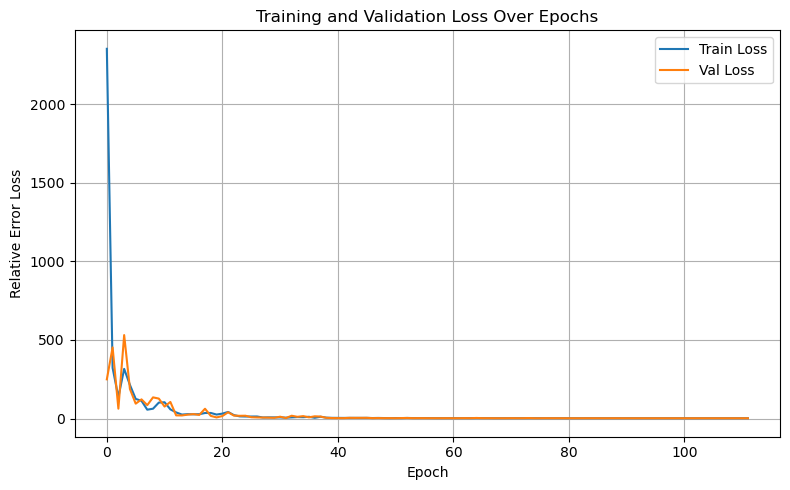

 Metrics saved to 'training_metrics_vgg_scaled_disamb.csv'


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Disambiguation--------------------
def select_best_symmetry_configuration(grid, scalar, label):
    best_score = -1
    best_config = None

    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()

        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)

        score = np.sum(g[g.shape[0]//2:, :g.shape[1]//2])  # bottom-left
        if score > best_score:
            best_score = score
            g_scaled = g * scalar  
            best_config = (g_scaled.copy(), l.copy())

    return best_config

# -------------------- Dataset --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, scaled_grids, flow_fields, transform=None):
        self.scaled_grids = scaled_grids.astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])              
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- VGG-Style Model --------------------
class VGGStyleHomogeneousCNN(nn.Module):
    def __init__(self):
        super(VGGStyleHomogeneousCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.features(x).squeeze(1)  

# -------------------- Loss --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, pred, target):
        return (torch.abs(pred - target) / (target + self.eps)).mean()

# -------------------- Evaluation --------------------
def evaluate_model(model, loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid, target in loader:
            grid, target = grid.to(device), target.to(device)
            pred = model(grid)
            total_loss += criterion(pred, target).item()
    return total_loss / len(loader)

# -------------------- Training --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=200, lr=5e-4, device='cuda'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()
    count_parameters(model)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid, target in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid, target = grid.to(device), target.to(device)
            pred = model(grid)
            loss = criterion(pred, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                early_stop_counter = 0
                torch.save(model.state_dict(), 'best_vgg_scaled_disamb.pth')
            else:
                early_stop_counter += 1
                if early_stop_counter >= early_stop_patience:
                    print("Early stopping triggered.")
                    break

    print("Training complete.")

    # Plot 
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Val Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_vgg_scaled_disamb.png")
    plt.show()

    # Save 
    pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    }).to_csv("training_metrics_vgg_scaled_disamb.csv", index=False)
    print(" Metrics saved to 'training_metrics_vgg_scaled_disamb.csv'")

    return model

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading & Training --------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

#disambiguation i scaling
scaled_grids = []
scaled_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]
    scalar = (params_df['delta_p'].iloc[i] * params_df['delta_A'].iloc[i]) / (
              params_df['visc'].iloc[i] * params_df['L'].iloc[i])
    g_scaled, l_best = select_best_symmetry_configuration(grid, scalar, label)
    scaled_grids.append(g_scaled)
    scaled_labels.append(l_best)

scaled_grids = np.array(scaled_grids)
flow_fields = np.array(scaled_labels)

# Data and split
dataset = ScaledGridDataset(scaled_grids, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(33)

# Train
model = VGGStyleHomogeneousCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=200, lr=5e-4, device=device)


## VGG DIMENSIONLESS NO AUGMENTATION

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 33

 Total trainable parameters: 286,561


Epoch 1/500: 100%|██████████| 43/43 [00:01<00:00, 32.13it/s]



Epoch 1 — Train Loss: 3565.312917
Epoch 1 — Val Loss: 879.048071


Epoch 2/500: 100%|██████████| 43/43 [00:00<00:00, 51.21it/s]


...


Epoch 106 — Train Loss: 4.594914
Epoch 106 — Val Loss: 4.574343


Epoch 107/500: 100%|██████████| 43/43 [00:00<00:00, 50.46it/s]



Epoch 107 — Train Loss: 4.592327
Epoch 107 — Val Loss: 4.647513


Epoch 108/500: 100%|██████████| 43/43 [00:00<00:00, 50.81it/s]



Epoch 108 — Train Loss: 4.581396
Epoch 108 — Val Loss: 4.554976
Early stopping triggered.


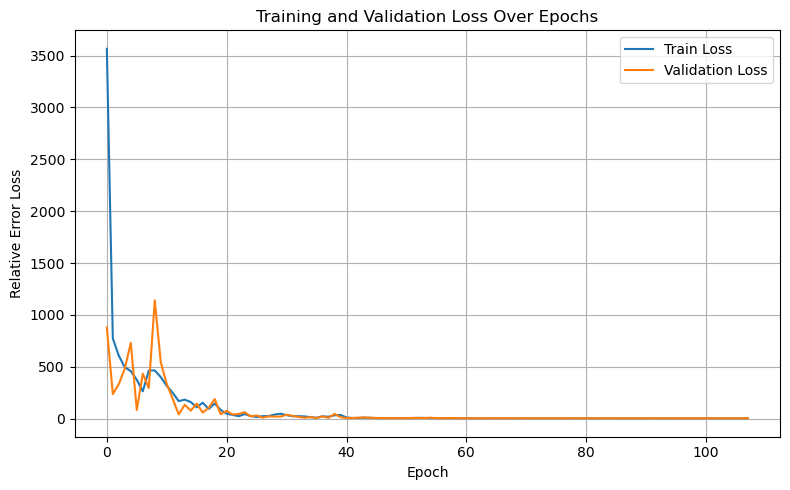

 Metrics saved to 'training_metrics_dimensionless_vgg.csv'


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Dataset Class --------------------
class PorousFlowDimensionlessDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)

        mu = params_df['visc'].values
        L = params_df['L'].values
        delta_p = params_df['delta_p'].values
        delta_A = params_df['delta_A'].values

        self.scales = (mu * L) / (delta_p * delta_A)
        self.scales = self.scales.astype(np.float32).reshape(-1, 1, 1)

        self.flow_fields = flow_fields.astype(np.float32) * self.scales
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.binary_grids[idx]).unsqueeze(0)
        label_tensor = torch.tensor(self.flow_fields[idx])
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- VGG-style Model --------------------
class VGGStyleDimensionlessCNN(nn.Module):
    def __init__(self):
        super(VGGStyleDimensionlessCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(128, 1, kernel_size=1)
        )

    def forward(self, x):
        out = self.cnn(x)            
        return out.squeeze(1)     

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        return (torch.abs(predictions - targets) / (targets + self.eps)).mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)
            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()
    count_parameters(model)

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                early_stop_counter = 0
                torch.save(model.state_dict(), 'best_model_dimensionless_vgg.pth')
            else:
                early_stop_counter += 1
                if early_stop_counter >= early_stop_patience:
                    print("Early stopping triggered.")
                    break

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader: plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_dimensionless_vgg.png")
    plt.show()

    # Save metrics
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_dimensionless_vgg.csv", index=False)
    print(" Metrics saved to 'training_metrics_dimensionless_vgg.csv'")

    return model

# -------------------- Parameter Counter --------------------
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Main --------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

binary_grids = np.load("train_inputs.npy")
flow_fields = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

dataset = PorousFlowDimensionlessDataset(binary_grids, params_df, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(33)

model = VGGStyleDimensionlessCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=500, lr=5e-4, device=device)


## VGG DIMENSIONLESS AUGMENTATIONS

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 30

 Total trainable parameters: 286,561


Epoch 1/500: 100%|██████████| 85/85 [00:02<00:00, 29.13it/s]



Epoch 1 — Train Loss: 6198.478376
Epoch 1 — Val Loss: 1735.506702


Epoch 2/500: 100%|██████████| 85/85 [00:02<00:00, 32.25it/s]


...


Epoch 79 — Train Loss: 5.935073
Epoch 79 — Val Loss: 5.799497


Epoch 80/500: 100%|██████████| 85/85 [00:02<00:00, 33.73it/s]



Epoch 80 — Train Loss: 5.749381
Epoch 80 — Val Loss: 6.251885


Epoch 81/500: 100%|██████████| 85/85 [00:02<00:00, 33.76it/s]



Epoch 81 — Train Loss: 5.954293
Epoch 81 — Val Loss: 5.971835
Early stopping triggered.


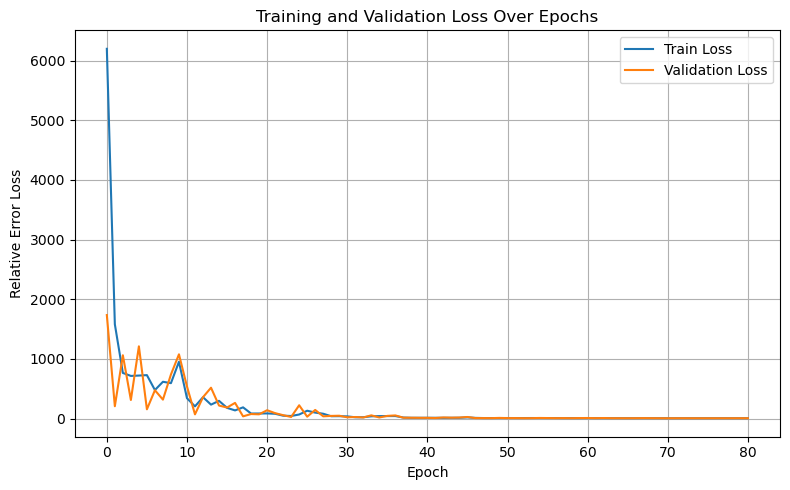

 Metrics saved to 'training_metrics_dimensionless_vgg.csv'


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Augmentation --------------------
def apply_symmetry_augmentations(grid, label):
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)
        augmented.append((g, l))
    return augmented



# -------------------- Dataset Class --------------------
class PorousFlowDimensionlessDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)

        mu = params_df['visc'].values
        L = params_df['L'].values
        delta_p = params_df['delta_p'].values
        delta_A = params_df['delta_A'].values

        self.scales = (mu * L) / (delta_p * delta_A)
        self.scales = self.scales.astype(np.float32).reshape(-1, 1, 1)

        self.flow_fields = flow_fields.astype(np.float32) * self.scales
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.binary_grids[idx]).unsqueeze(0)
        label_tensor = torch.tensor(self.flow_fields[idx])
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- VGG-style Model --------------------
class VGGStyleDimensionlessCNN(nn.Module):
    def __init__(self):
        super(VGGStyleDimensionlessCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(128, 1, kernel_size=1)
        )

    def forward(self, x):
        out = self.cnn(x)           
        return out.squeeze(1)      

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        return (torch.abs(predictions - targets) / (targets + self.eps)).mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)
            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()
    count_parameters(model)

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                early_stop_counter = 0
                torch.save(model.state_dict(), 'best_model_dimensionless_vgg_3.pth')
            else:
                early_stop_counter += 1
                if early_stop_counter >= early_stop_patience:
                    print("Early stopping triggered.")
                    break

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader: plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_dimensionless_vgg_3.png")
    plt.show()

    # Save 
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_dimensionless_vgg_3.csv", index=False)
    print(" Metrics saved to 'training_metrics_dimensionless_vgg.csv'")

    return model

# -------------------- Parameter Counter --------------------
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params



device = 'cuda' if torch.cuda.is_available() else 'cpu'


binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

# scaling factor
mu = params_df['visc'].values
L = params_df['L'].values
delta_p = params_df['delta_p'].values
delta_A = params_df['delta_A'].values
scales = ((mu * L) / (delta_p * delta_A)).astype(np.float32).reshape(-1, 1, 1)

# augmentations
augmented_grids = []
augmented_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i] * scales[i]  # make it dimensionless

    augmented = apply_symmetry_augmentations(grid, label)
    for g_aug, l_aug in augmented:
        augmented_grids.append(g_aug)
        augmented_labels.append(l_aug)


binary_grids = np.array(augmented_grids)
flow_fields = np.array(augmented_labels)


params_df_aug = params_df.loc[np.repeat(params_df.index.values, 4)].reset_index(drop=True)


dataset = PorousFlowDimensionlessDataset(binary_grids, params_df_aug, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

set_seed(30)

# Train
model = VGGStyleDimensionlessCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=500, lr=5e-4, device=device)



## VGG DIMENSIONLESS DISAMBIGUATING THE SYMMETRY

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 33

 Total trainable parameters: 286,561


Epoch 1/200: 100%|██████████| 43/43 [00:01<00:00, 37.54it/s]



Epoch 1 — Train Loss: 3457.947786
Epoch 1 — Val Loss: 227.027545


Epoch 2/200: 100%|██████████| 43/43 [00:00<00:00, 51.73it/s]


...


Epoch 142 — Train Loss: 7.237298
Epoch 142 — Val Loss: 7.200358


Epoch 143/200: 100%|██████████| 43/43 [00:00<00:00, 50.83it/s]



Epoch 143 — Train Loss: 7.227151
Epoch 143 — Val Loss: 7.190018


Epoch 144/200: 100%|██████████| 43/43 [00:00<00:00, 50.01it/s]



Epoch 144 — Train Loss: 7.126739
Epoch 144 — Val Loss: 7.187255
Early stopping triggered.


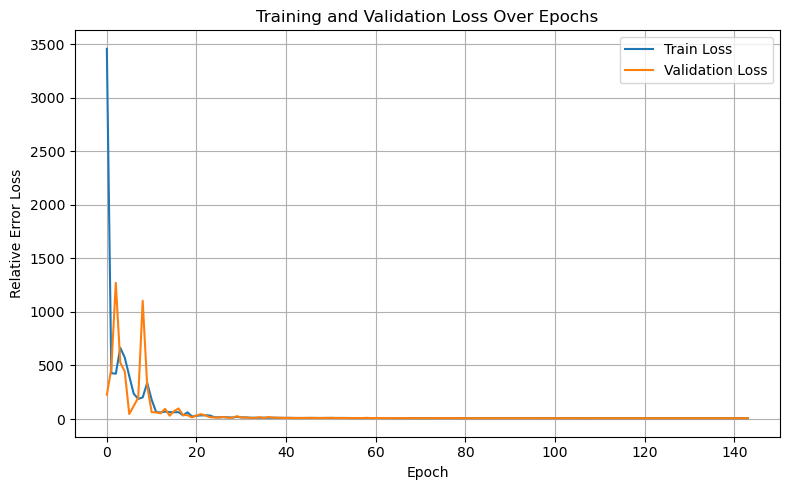

 Metrics saved to 'training_metrics_dimensionless_vgg_disamb_2.csv'


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

def select_best_symmetry_configuration(grid, label):

    best_score = -1
    best_config = None

    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()

        # Apply flip
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)

        # bottom-left quadrant
        h, w = g.shape
        bl_quadrant = g[h//2:, :w//2]
        score = np.sum(bl_quadrant == 1)

        if score > best_score:
            best_score = score
            best_config = (g.copy(), l.copy())

    return best_config

# -------------------- Dataset Class --------------------
class PorousFlowDimensionlessDataset(Dataset):
    def __init__(self, binary_grids, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.binary_grids[idx]).unsqueeze(0)
        label_tensor = torch.tensor(self.flow_fields[idx])
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- VGG-style Model --------------------
class VGGStyleDimensionlessCNN(nn.Module):
    def __init__(self):
        super(VGGStyleDimensionlessCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),

            nn.Conv2d(128, 1, kernel_size=1)
        )

    def forward(self, x):
        out = self.cnn(x)            
        return out.squeeze(1)      

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        return (torch.abs(predictions - targets) / (targets + self.eps)).mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)
            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()
    count_parameters(model)

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                early_stop_counter = 0
                torch.save(model.state_dict(), 'best_model_dimensionless_vgg_disamb_2.pth')
            else:
                early_stop_counter += 1
                if early_stop_counter >= early_stop_patience:
                    print("Early stopping triggered.")
                    break


    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader: plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_dimensionless_vgg_disamb_2.png")
    plt.show()

    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_dimensionless_vgg_disamb.csv", index=False)
    print(" Metrics saved to 'training_metrics_dimensionless_vgg_disamb_2.csv'")

    return model

# -------------------- Parameter Counter --------------------
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params


device = 'cuda' if torch.cuda.is_available() else 'cpu'


binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")


mu = params_df['visc'].values
L = params_df['L'].values
delta_p = params_df['delta_p'].values
delta_A = params_df['delta_A'].values
scales = ((mu * L) / (delta_p * delta_A)).astype(np.float32).reshape(-1, 1, 1)

# dimensionless targets and apply disambiguation
disambiguated_grids = []
disambiguated_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
  
    label = flow_fields_raw[i] * scales[i]  
    
    #  best config
    best_grid, best_label = select_best_symmetry_configuration(grid, label)
    disambiguated_grids.append(best_grid)
    disambiguated_labels.append(best_label)

binary_grids = np.array(disambiguated_grids)
flow_fields = np.array(disambiguated_labels)

dataset = PorousFlowDimensionlessDataset(binary_grids, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(33)

# Train model
model = VGGStyleDimensionlessCNN()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=200, lr=5e-4, device=device)

## U NET HOMOGENEOUS NO AUGMENTATIONS

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 42

 Total trainable parameters: 29,321


Epoch 1/500: 100%|██████████| 43/43 [00:00<00:00, 95.82it/s] 



Epoch 1 — Train Loss: 2022.041243
Epoch 1 — Val Loss: 601.733374


Epoch 2/500: 100%|██████████| 43/43 [00:00<00:00, 220.13it/s]


...


Epoch 77 — Train Loss: 0.651094
Epoch 77 — Val Loss: 0.521947


Epoch 78/500: 100%|██████████| 43/43 [00:00<00:00, 250.57it/s]



Epoch 78 — Train Loss: 0.582738
Epoch 78 — Val Loss: 0.505417


Epoch 79/500: 100%|██████████| 43/43 [00:00<00:00, 194.55it/s]



Epoch 79 — Train Loss: 0.584036
Epoch 79 — Val Loss: 0.532202
Early stopping triggered.


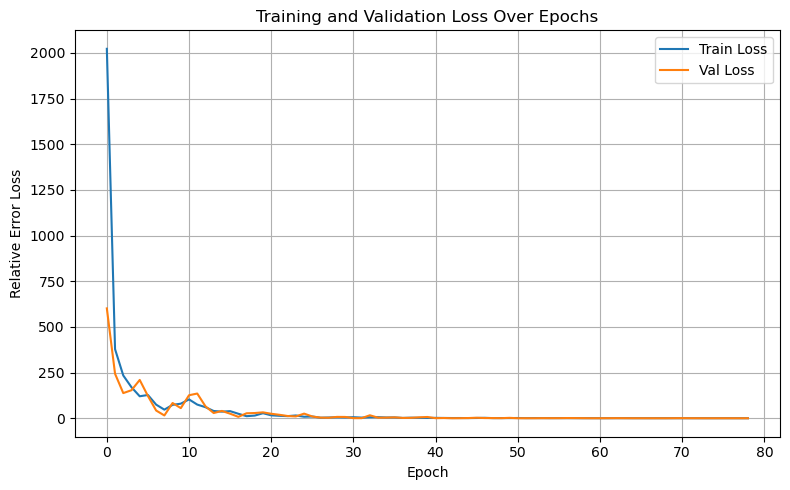

 Training metrics saved to 'training_metrics_unet_scaled.csv'


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")


# -------------------- Dataset Class --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.scalars = (params_df['delta_p'] * params_df['delta_A']) / (params_df['visc'] * params_df['L'])
        self.scalars = self.scalars.values.astype(np.float32).reshape(-1, 1, 1)
        self.binary_grids = binary_grids.astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.scaled_grids = (self.binary_grids * self.scalars).astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])               
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- U-Net Style Model--------------------
class TinyUNetHomogeneous(nn.Module):
    def __init__(self):
        super(TinyUNetHomogeneous, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)  # 32x64 to 16x32

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)  # 16x32 to 8x16

        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(16, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1), nn.ReLU()
        )

        self.final = nn.Conv2d(8, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.bottleneck(self.pool2(x2))

        x = self.up2(x3)
        x = self.dec2(torch.cat([x, x2], dim=1))

        x = self.up1(x)
        x = self.dec1(torch.cat([x, x1], dim=1))

        return self.final(x).squeeze(1)

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        return (torch.abs(pred - target) / (target + self.eps)).mean()

# -------------------- Evaluation --------------------
def evaluate_model(model, loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid, target in loader:
            grid, target = grid.to(device), target.to(device)
            pred = model(grid)
            total_loss += criterion(pred, target).item()
    return total_loss / len(loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=500, lr=5e-4, device='cuda'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()
    count_parameters(model)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    stop_counter = 0
    stop_patience = 10

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for grid, target in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid, target = grid.to(device), target.to(device)
            pred = model(grid)
            loss = criterion(pred, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train = total_loss / len(train_loader)
        train_losses.append(avg_train)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train:.6f}")

        if val_loader:
            val = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val)
            print(f"Epoch {epoch+1} — Val Loss: {val:.6f}")
            scheduler.step(val)

            if val < best_val_loss:
                best_val_loss = val
                stop_counter = 0
                torch.save(model.state_dict(), 'best_unet_scaled.pth')
            else:
                stop_counter += 1
                if stop_counter >= stop_patience:
                    print("Early stopping triggered.")
                    break

  
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader: plt.plot(val_losses, label='Val Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_unet_scaled.png")
    plt.show()

    pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    }).to_csv("training_metrics_unet_scaled.csv", index=False)

    print(" Training metrics saved to 'training_metrics_unet_scaled.csv'")
    return model

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n Total trainable parameters: {total:,}")
    return total


device = 'cuda' if torch.cuda.is_available() else 'cpu'

binary_grids = np.load("train_inputs.npy")
flow_fields = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

dataset = ScaledGridDataset(binary_grids, params_df, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

set_seed(42)

model = TinyUNetHomogeneous()
trained_model = train_model(model, train_loader, val_loader, num_epochs=500, lr=5e-4, device=device)


## HOMOGENEOUS U-NET AUGMENT

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 42
Layer-wise parameter count:
enc1.0.weight                  | 72
enc1.0.bias                    | 8
enc1.2.weight                  | 576
enc1.2.bias                    | 8
enc2.0.weight                  | 1152
enc2.0.bias                    | 16
enc2.2.weight                  | 2304
enc2.2.bias                    | 16
bottleneck.0.weight            | 4608
bottleneck.0.bias              | 32
bottleneck.2.weight            | 9216
bottleneck.2.bias              | 32
up2.weight                     | 2048
up2.bias                       | 16
dec2.0.weight                  | 4608
dec2.0.bias                    | 16
dec2.2.weight                  | 2304
dec2.2.bias                    | 16
up1.weight                     | 512
up1.bias                       | 8
dec1.0.weight                  | 1152
dec1.0.bias                    | 8
dec1.2.weight                  | 576
dec1.2.bias                    | 8
final.weight                   | 8
final.bias                     | 1

 

Epoch 1/1000: 100%|██████████| 169/169 [00:00<00:00, 185.00it/s]



Epoch 1 — Train Loss: 990.353727
Epoch 1 — Val Loss: 196.484164


Epoch 2/1000: 100%|██████████| 169/169 [00:00<00:00, 262.84it/s]


...


Epoch 73 — Train Loss: 0.312914
Epoch 73 — Val Loss: 0.330413


Epoch 74/1000: 100%|██████████| 169/169 [00:00<00:00, 254.42it/s]



Epoch 74 — Train Loss: 0.287800
Epoch 74 — Val Loss: 0.336540


Epoch 75/1000: 100%|██████████| 169/169 [00:00<00:00, 244.50it/s]



Epoch 75 — Train Loss: 0.285612
Epoch 75 — Val Loss: 0.327621
Early stopping triggered.
Training complete.


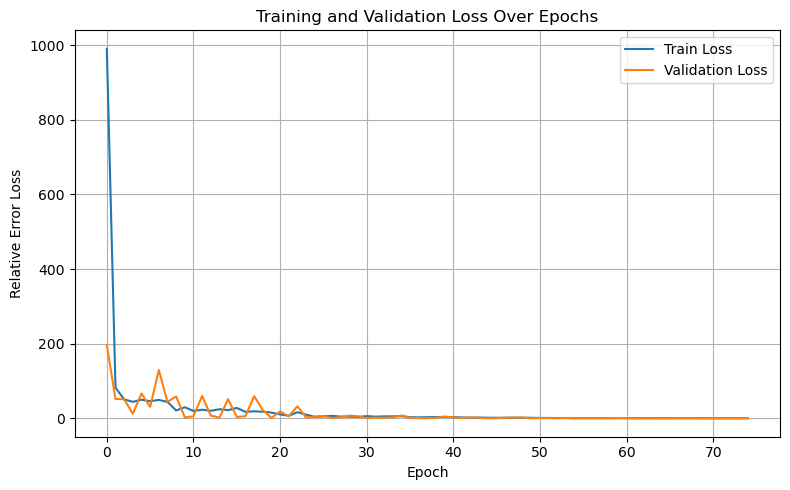

 Training metrics saved


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Augmentation Function --------------------
def apply_symmetry_augmentations(grid, scalar, label):
    """
    Applies horizontal, vertical, both flips to grid and label.
    Scalar remains unchanged. Returns list of (grid, scalar, label) tuples.
    """
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g = grid.copy()
        l = label.copy()
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)
        augmented.append((g, scalar, l))
    return augmented

# -------------------- Dataset Class --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, binary_grids, scalars, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.scalars = scalars.astype(np.float32).reshape(-1, 1, 1)
        self.flow_fields = flow_fields.astype(np.float32)
        self.scaled_grids = (self.binary_grids * self.scalars).astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)
        label_tensor = torch.tensor(self.flow_fields[idx])
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- Model Definition --------------------
class TinyUNetHomogeneous(nn.Module):
    def __init__(self):
        super(TinyUNetHomogeneous, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(16, 8, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )

        self.final = nn.Conv2d(8, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.bottleneck(self.pool2(x2))
        x = self.up2(x3)
        x = self.dec2(torch.cat([x, x2], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, x1], dim=1))
        return self.final(x).squeeze(1)




# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    # Track loss values
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_unet_homogen_aug_4_longer.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    # Plot 
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_unet_aug_4_longer.png")
    plt.show()

 
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_unet_aug_4_longer.csv", index=False)
    print(" Training metrics saved")

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading and Training --------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'


binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")


augmented_grids = []
augmented_scalars = []
augmented_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]
    scalar = (params_df['delta_p'].iloc[i] * params_df['delta_A'].iloc[i]) / (
              params_df['visc'].iloc[i] * params_df['L'].iloc[i])
    
    augmented = apply_symmetry_augmentations(grid, scalar, label)
    for g, s, l in augmented:
        augmented_grids.append(g)
        augmented_scalars.append(s)
        augmented_labels.append(l)


binary_grids = np.array(augmented_grids)
scalars = np.array(augmented_scalars).reshape(-1, 1, 1)
flow_fields = np.array(augmented_labels)


dataset = ScaledGridDataset(binary_grids, scalars, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(42)

# Train
model = TinyUNetHomogeneous()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=1000, lr=3e-4, device=device)

## U-NET HOMOGENEOUS DISAMBIGUATING THE SYMMETRY

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 42
Layer-wise parameter count:
enc1.0.weight                  | 72
enc1.0.bias                    | 8
enc1.2.weight                  | 576
enc1.2.bias                    | 8
enc2.0.weight                  | 1152
enc2.0.bias                    | 16
enc2.2.weight                  | 2304
enc2.2.bias                    | 16
bottleneck.0.weight            | 4608
bottleneck.0.bias              | 32
bottleneck.2.weight            | 9216
bottleneck.2.bias              | 32
up2.weight                     | 2048
up2.bias                       | 16
dec2.0.weight                  | 4608
dec2.0.bias                    | 16
dec2.2.weight                  | 2304
dec2.2.bias                    | 16
up1.weight                     | 512
up1.bias                       | 8
dec1.0.weight                  | 1152
dec1.0.bias                    | 8
dec1.2.weight                  | 576
dec1.2.bias                    | 8
final.weight                   | 8
final.bias                     | 1

 

Epoch 1/500: 100%|██████████| 43/43 [00:00<00:00, 111.04it/s]



Epoch 1 — Train Loss: 2018.679288
Epoch 1 — Val Loss: 566.156982


Epoch 2/500: 100%|██████████| 43/43 [00:00<00:00, 285.87it/s]


...


Epoch 64 — Train Loss: 0.879710
Epoch 64 — Val Loss: 0.680969


Epoch 65/500: 100%|██████████| 43/43 [00:00<00:00, 224.61it/s]



Epoch 65 — Train Loss: 0.708984
Epoch 65 — Val Loss: 0.734121


Epoch 66/500: 100%|██████████| 43/43 [00:00<00:00, 241.25it/s]



Epoch 66 — Train Loss: 0.772755
Epoch 66 — Val Loss: 0.669995
Early stopping triggered.
Training complete.


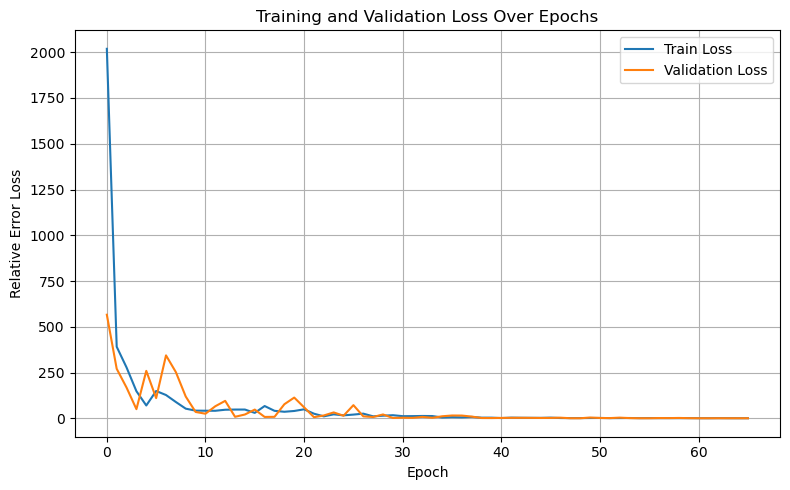

 Training metrics saved


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")
    
# -------------------- Symmetry Disambiguation --------------------
def select_best_symmetry_configuration(grid, scalar, label):
    best_score = -1
    best_config = None

    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()

        # Apply flip
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)

        # bottom-left quadrant
        h, w = g.shape
        bl_quadrant = g[h//2:, :w//2]
        score = np.sum(bl_quadrant == 1)

        if score > best_score:
            best_score = score
            best_config = (g.copy(), scalar, l.copy())

    return best_config

# -------------------- Dataset Class --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, binary_grids, scalars, flow_fields, transform=None):
        self.scaled_grids = (binary_grids * scalars.reshape(-1, 1, 1)).astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0) 
        label_tensor = torch.tensor(self.flow_fields[idx])               
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- Model Definition --------------------
class TinyUNetHomogeneous(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(16, 8, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )

        self.final = nn.Conv2d(8, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.bottleneck(self.pool2(x2))

        x = self.up2(x3)
        x = self.dec2(torch.cat([x, x2], dim=1))

        x = self.up1(x)
        x = self.dec1(torch.cat([x, x1], dim=1))

        return self.final(x).squeeze(1)


# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):

            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_unet_homogen_disamb_8.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    # Plot loss
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_unet_disamb)8.png")
    plt.show()

    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_unet_disamb_8.csv", index=False)
    print(" Training metrics saved")

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading + Training --------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'


binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

disamb_grids = []
disamb_scalars = []
disamb_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]
    scalar = (params_df['delta_p'][i] * params_df['delta_A'][i]) / (
             params_df['visc'][i] * params_df['L'][i])
    
    best_grid, best_scalar, best_label = select_best_symmetry_configuration(grid, scalar, label)
    disamb_grids.append(best_grid)
    disamb_scalars.append(best_scalar)
    disamb_labels.append(best_label)

binary_grids = np.array(disamb_grids)
scalars = np.array(disamb_scalars)
flow_fields = np.array(disamb_labels)

dataset = ScaledGridDataset(binary_grids, scalars, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(42)

# Train
model = TinyUNetHomogeneous()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=500, lr=5e-4, device=device)

## U-NET DIMENSIONLESS NO AUGMENTATION

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 42
Layer-wise parameter count:
enc1.0.weight                  | 72
enc1.0.bias                    | 8
enc1.2.weight                  | 576
enc1.2.bias                    | 8
enc2.0.weight                  | 1152
enc2.0.bias                    | 16
enc2.2.weight                  | 2304
enc2.2.bias                    | 16
bottleneck.0.weight            | 4608
bottleneck.0.bias              | 32
bottleneck.2.weight            | 9216
bottleneck.2.bias              | 32
up2.weight                     | 2048
up2.bias                       | 16
dec2.0.weight                  | 4608
dec2.0.bias                    | 16
dec2.2.weight                  | 2304
dec2.2.bias                    | 16
up1.weight                     | 512
up1.bias                       | 8
dec1.0.weight                  | 1152
dec1.0.bias                    | 8
dec1.2.weight                  | 576
dec1.2.bias                    | 8
final.weight                   | 8
final.bias                     | 1

 

Epoch 1/500: 100%|██████████| 43/43 [00:00<00:00, 106.81it/s]



Epoch 1 — Train Loss: 1084.159218
Epoch 1 — Val Loss: 239.121582


Epoch 2/500: 100%|██████████| 43/43 [00:00<00:00, 276.01it/s]


...


Epoch 498 — Train Loss: 8.981863
Epoch 498 — Val Loss: 9.140076


Epoch 499/500: 100%|██████████| 43/43 [00:00<00:00, 280.82it/s]



Epoch 499 — Train Loss: 9.020092
Epoch 499 — Val Loss: 9.140090


Epoch 500/500: 100%|██████████| 43/43 [00:00<00:00, 242.40it/s]



Epoch 500 — Train Loss: 9.014572
Epoch 500 — Val Loss: 9.139926
Training complete.


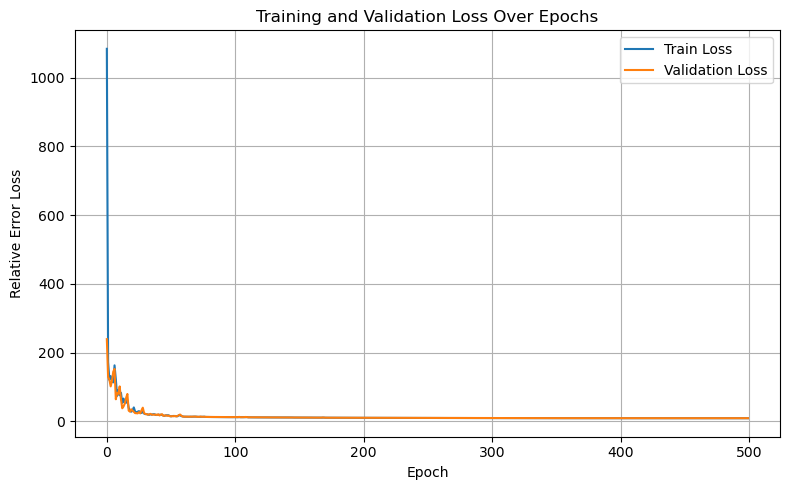

 Training metrics saved


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Dataset Class --------------------
class PorousFlowDimensionlessDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)

        mu = params_df['visc'].values
        L = params_df['L'].values
        delta_p = params_df['delta_p'].values
        delta_A = params_df['delta_A'].values

        self.scales = (mu * L) / (delta_p * delta_A) 
        self.scales = self.scales.astype(np.float32).reshape(-1, 1, 1)
        self.flow_fields = flow_fields.astype(np.float32) * self.scales
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.binary_grids[idx]).unsqueeze(0)  
        label_tensor = torch.tensor(self.flow_fields[idx])               

        if self.transform:
            grid_tensor = self.transform(grid_tensor)

        return grid_tensor, label_tensor

# -------------------- Dimensionless U-Net Model --------------------
class DimensionlessUNet(nn.Module):
    def __init__(self):
        super(DimensionlessUNet, self).__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)  # 32x64 to 16x32

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)  # 16x32 to 8x16

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU()
        )

        # Decoder
        self.up2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)  
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2) 
        self.dec1 = nn.Sequential(
            nn.Conv2d(16, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1), nn.ReLU()
        )

        self.final = nn.Conv2d(8, 1, kernel_size=1)

    def forward(self, grid):
        # Encoder
        x1 = self.enc1(grid)               
        x2 = self.enc2(self.pool1(x1))     
        x3 = self.bottleneck(self.pool2(x2))  

        # Decoder
        x = self.up2(x3)                              
        x = self.dec2(torch.cat([x, x2], dim=1))      

        x = self.up1(x)                               
        x = self.dec1(torch.cat([x, x1], dim=1))     

        out = self.final(x)                           
        return out.squeeze(1)                         

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10


    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_unet_dimensionless_332.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    # Plot loss
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_unet_dimensionless_332.png")
    plt.show()

    # Save 
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_unet_dimensionless_332.csv", index=False)
    print(" Training metrics saved")

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading + Training --------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

binary_grids = np.load("train_inputs.npy")
flow_fields = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

dataset = PorousFlowDimensionlessDataset(binary_grids, params_df, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(42)

# Train
model = DimensionlessUNet()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=500, lr=5e-4, device=device)

## U NET DIMENSIONLESS AUGMENT

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 42


Epoch 1/500: 100%|██████████| 169/169 [00:00<00:00, 178.65it/s]


Epoch 1 — Train Loss: 389.717182
Epoch 1 — Val Loss: 86.584496


Epoch 2/500: 100%|██████████| 169/169 [00:00<00:00, 276.03it/s]


...

Epoch 498 — Train Loss: 0.796066
Epoch 498 — Val Loss: 0.819743


Epoch 499/500: 100%|██████████| 169/169 [00:00<00:00, 271.33it/s]


Epoch 499 — Train Loss: 0.795881
Epoch 499 — Val Loss: 0.816824


Epoch 500/500: 100%|██████████| 169/169 [00:00<00:00, 295.59it/s]


Epoch 500 — Train Loss: 0.794778
Epoch 500 — Val Loss: 0.816728


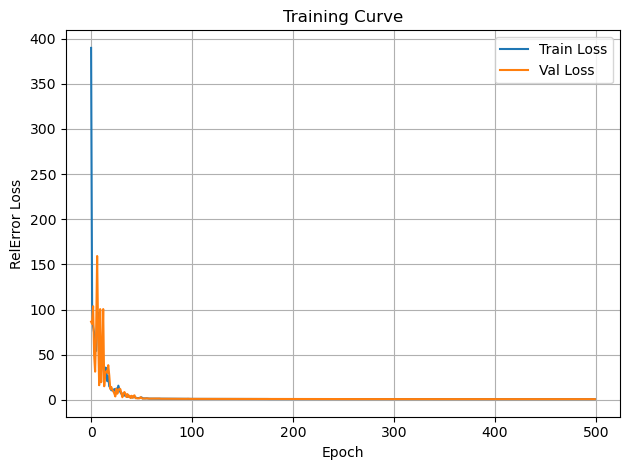

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Augmentation Function --------------------
def apply_symmetry_augmentations(grid, label):
    """
    Applies symmetry flips to both grid and label, ensuring tensors are contiguous.
    """
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g = grid.copy()
        l = label.copy()
        if flip == 'h':
            g = np.flip(g, axis=1).copy()
            l = np.flip(l, axis=1).copy()
        elif flip == 'v':
            g = np.flip(g, axis=0).copy()
            l = np.flip(l, axis=0).copy()
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1).copy()
            l = np.flip(np.flip(l, axis=0), axis=1).copy()
        augmented.append((g, l))
    return augmented

# -------------------- Augmented Dataset --------------------
class PorousFlowDimensionlessAugDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.grid_list = []
        self.label_list = []

        mu = params_df['visc'].values
        L = params_df['L'].values
        delta_p = params_df['delta_p'].values
        delta_A = params_df['delta_A'].values
        scales = (mu * L) / (delta_p * delta_A)

        for i in range(len(binary_grids)):
            grid = binary_grids[i]
            label = flow_fields[i]
            scale = scales[i]

            augmented = apply_symmetry_augmentations(grid, label)
            for g_aug, l_aug in augmented:
                self.grid_list.append(torch.tensor(g_aug, dtype=torch.float32).unsqueeze(0))  
                self.label_list.append(torch.tensor(l_aug * scale, dtype=torch.float32))     

        self.transform = transform

    def __len__(self):
        return len(self.grid_list)

    def __getitem__(self, idx):
        grid = self.grid_list[idx]
        label = self.label_list[idx]
        if self.transform:
            grid = self.transform(grid)
        return grid, label


# -------------------- U-Net Model --------------------
class TinyUNetDimensionless(nn.Module):
    def __init__(self):
        super(TinyUNetDimensionless, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )

        self.final = nn.Conv2d(8, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)              
        x2 = self.enc2(self.pool1(x1))  
        x3 = self.bottleneck(self.pool2(x2))  

        x = self.up2(x3)                     
        x = self.dec2(torch.cat([x, x2], dim=1))  

        x = self.up1(x)                      
        x = self.dec1(torch.cat([x, x1], dim=1)) 

        out = self.final(x)  
        return out.squeeze(1)


# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        return (torch.abs(predictions - targets) / (targets + self.eps)).mean()


# -------------------- Evaluation Function --------------------
def evaluate_model(model, loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)
            pred = model(grid_batch)
            loss = criterion(pred, target_batch)
            total_loss += loss.item()
    return total_loss / len(loader)


# -------------------- Training --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=100, lr=1e-3, device='cuda'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    patience = 10

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)
            pred = model(grid_batch)
            loss = criterion(pred, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        print(f"Epoch {epoch+1} — Train Loss: {train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model_dimensionless_unet_aug.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print(" Early stopping.")
                break

    # Plot
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.grid(True)
    plt.title("Training Curve"); plt.xlabel("Epoch"); plt.ylabel("RelError Loss")
    plt.tight_layout(); plt.savefig("loss_curve_dimensionless_unet_aug.png")
    plt.show()

    return model


device = 'cuda' if torch.cuda.is_available() else 'cpu'

binary_grids = np.load("train_inputs.npy")
flow_fields = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")


dataset = PorousFlowDimensionlessAugDataset(binary_grids, params_df, flow_fields)


train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


set_seed(42)
model = TinyUNetDimensionless()
trained_model = train_model(model, train_loader, val_loader, num_epochs=500, lr=5e-4, device=device)


## U-NET DIMENSIONLESS DISAMBIGUATING THE SYMMETRY

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 42
Layer-wise parameter count:
enc1.0.weight                  | 72
enc1.0.bias                    | 8
enc1.2.weight                  | 576
enc1.2.bias                    | 8
enc2.0.weight                  | 1152
enc2.0.bias                    | 16
enc2.2.weight                  | 2304
enc2.2.bias                    | 16
bottleneck.0.weight            | 4608
bottleneck.0.bias              | 32
bottleneck.2.weight            | 9216
bottleneck.2.bias              | 32
up2.weight                     | 2048
up2.bias                       | 16
dec2.0.weight                  | 4608
dec2.0.bias                    | 16
dec2.2.weight                  | 2304
dec2.2.bias                    | 16
up1.weight                     | 512
up1.bias                       | 8
dec1.0.weight                  | 1152
dec1.0.bias                    | 8
dec1.2.weight                  | 576
dec1.2.bias                    | 8
final.weight                   | 8
final.bias                     | 1

 

Epoch 1/1000: 100%|██████████| 43/43 [00:00<00:00, 93.07it/s] 



Epoch 1 — Train Loss: 1085.846414
Epoch 1 — Val Loss: 221.247958


Epoch 2/1000: 100%|██████████| 43/43 [00:00<00:00, 260.91it/s]


...


Epoch 998 — Train Loss: 7.660282
Epoch 998 — Val Loss: 7.519632


Epoch 999/1000: 100%|██████████| 43/43 [00:00<00:00, 221.23it/s]



Epoch 999 — Train Loss: 7.623833
Epoch 999 — Val Loss: 7.518474


Epoch 1000/1000: 100%|██████████| 43/43 [00:00<00:00, 224.08it/s]



Epoch 1000 — Train Loss: 7.636716
Epoch 1000 — Val Loss: 7.517357
Training complete.


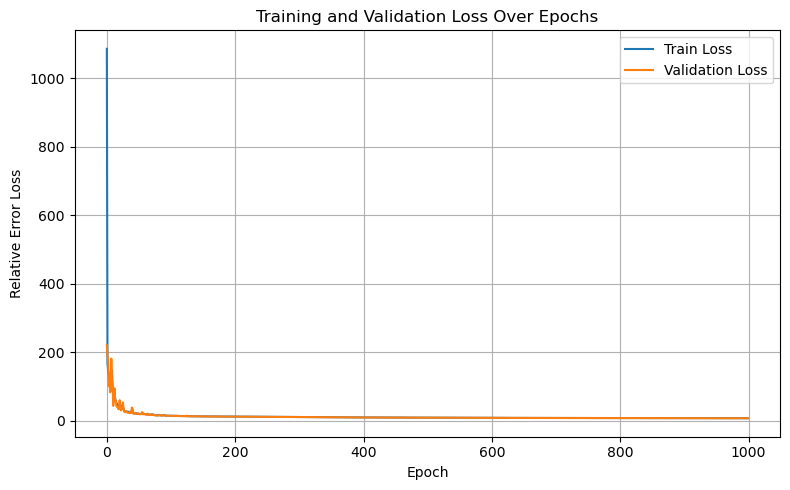

 Training metrics saved


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Symmetry Disambiguation  --------------------
def select_best_symmetry_configuration(grid, label):
    best_score = -1
    best_config = None

    for flip in [None, 'h', 'v', 'hv']:
        g, l = grid.copy(), label.copy()

        # Apply flip
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)

        #  bottom-left quadrant
        h, w = g.shape
        bl_quadrant = g[h//2:, :w//2]
        score = np.sum(bl_quadrant == 1)

        if score > best_score:
            best_score = score
            best_config = (g.copy(), l.copy())

    return best_config

# -------------------- Dataset Class --------------------
class PorousFlowDimensionlessDataset(Dataset):
    def __init__(self, binary_grids, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.binary_grids[idx]).unsqueeze(0) 
        label_tensor = torch.tensor(self.flow_fields[idx])               

        if self.transform:
            grid_tensor = self.transform(grid_tensor)

        return grid_tensor, label_tensor

# -------------------- Dimensionless U-Net Model --------------------
class DimensionlessUNet(nn.Module):
    def __init__(self):
        super(DimensionlessUNet, self).__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)  

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)  

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU()
        )

        # Decoder
        self.up2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2) 
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2) 
        self.dec1 = nn.Sequential(
            nn.Conv2d(16, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1), nn.ReLU()
        )

        self.final = nn.Conv2d(8, 1, kernel_size=1)

    def forward(self, grid):
        # Encoder
        x1 = self.enc1(grid)               
        x2 = self.enc2(self.pool1(x1))     
        x3 = self.bottleneck(self.pool2(x2))  

        # Decoder
        x = self.up2(x3)                             
        x = self.dec2(torch.cat([x, x2], dim=1))     

        x = self.up1(x)                               
        x = self.dec1(torch.cat([x, x1], dim=1))      

        out = self.final(x)                          
        return out.squeeze(1)                         

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    # Track loss values
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_unet_dimensionless_disamb_8.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")


    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_unet_dimensionless_disamb_8.png")
    plt.show()


    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_unet_dimensionless_disamb_8.csv", index=False)
    print(" Training metrics saved")

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# --------------------  Training --------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'

binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

mu = params_df['visc'].values
L = params_df['L'].values
delta_p = params_df['delta_p'].values
delta_A = params_df['delta_A'].values
scales = ((mu * L) / (delta_p * delta_A)).astype(np.float32).reshape(-1, 1, 1)

# Scale dimensionless
flow_fields_dimensionless = flow_fields_raw * scales

disambiguated_grids = []
disambiguated_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_dimensionless[i]
    
    # Select best configuration
    best_grid, best_label = select_best_symmetry_configuration(grid, label)
    disambiguated_grids.append(best_grid)
    disambiguated_labels.append(best_label)

binary_grids = np.array(disambiguated_grids)
flow_fields = np.array(disambiguated_labels)

dataset = PorousFlowDimensionlessDataset(binary_grids, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(42)

# Train
model = DimensionlessUNet()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=1000, lr=5e-4, device=device)

## ANOTHER U NET HOMOGENEOUS NO AUGMENT

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Using device: cuda
Random seed set to 69
Layer-wise parameter count:
inc.double_conv.0.weight       | 576
inc.double_conv.0.bias         | 64
inc.double_conv.2.weight       | 36864
inc.double_conv.2.bias         | 64
down1.maxpool_conv.1.double_conv.0.weight | 73728
down1.maxpool_conv.1.double_conv.0.bias | 128
down1.maxpool_conv.1.double_conv.2.weight | 147456
down1.maxpool_conv.1.double_conv.2.bias | 128
down2.maxpool_conv.1.double_conv.0.weight | 294912
down2.maxpool_conv.1.double_conv.0.bias | 256
down2.maxpool_conv.1.double_conv.2.weight | 589824
down2.maxpool_conv.1.double_conv.2.bias | 256
down3.maxpool_conv.1.double_conv.0.weight | 1179648
down3.maxpool_conv.1.double_conv.0.bias | 512
down3.maxpool_conv.1.double_conv.2.weight | 2359296
down3.maxpool_conv.1.double_conv.2.bias | 512
scalar_mlp.0.weight            | 32
scalar_mlp.0.bias              | 32
scalar_mlp.2.weight            | 2048
scalar_mlp.2.bias              | 64
scalar_mlp.4.weight            | 32768
scalar_mlp.4.bi

Epoch 1/500: 100%|██████████| 43/43 [00:01<00:00, 29.29it/s]



Epoch 1 — Train Loss: 2042.349005
Epoch 1 — Val Loss: 531.510547


Epoch 2/500: 100%|██████████| 43/43 [00:01<00:00, 36.43it/s]


...


Epoch 425 — Train Loss: 5.264152
Epoch 425 — Val Loss: 5.549902


Epoch 426/500: 100%|██████████| 43/43 [00:01<00:00, 35.33it/s]



Epoch 426 — Train Loss: 5.237310
Epoch 426 — Val Loss: 5.550738


Epoch 427/500: 100%|██████████| 43/43 [00:01<00:00, 35.28it/s]



Epoch 427 — Train Loss: 5.263489
Epoch 427 — Val Loss: 5.550241
Early stopping triggered.
Training complete.


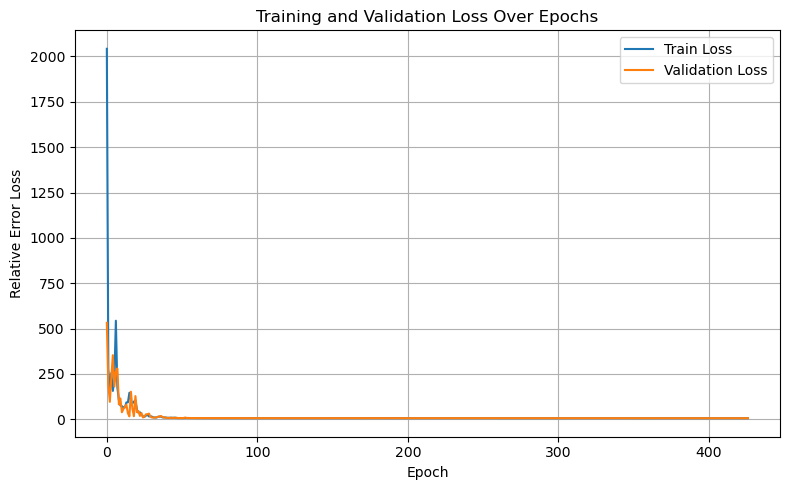

 Training metrics saved to 'training_metrics_unet.csv'


In [ ]:
def set_seed(seed):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")
    
# -------------------- Dataset Class --------------------
class PorousFlowHomogeneousDataset(Dataset):
    def __init__(self, binary_grids, params_df, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.scalars = (params_df['delta_p'] * params_df['delta_A']) / (params_df['visc'] * params_df['L'])
        self.scalars = self.scalars.values.astype(np.float32).reshape(-1, 1)
        self.flow_fields = flow_fields.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.binary_grids)

    def __getitem__(self, idx):
        grid = self.binary_grids[idx]
        grid_tensor = torch.tensor(grid).unsqueeze(0)  
        scalar_input = torch.tensor(self.scalars[idx]) 
        label = torch.tensor(self.flow_fields[idx])     

        if self.transform:
            grid_tensor = self.transform(grid_tensor)

        return (grid_tensor, scalar_input), label

# -------------------- U-Net Building Blocks --------------------
class DoubleConv(nn.Module):
    """Double Convolution block as shown in the slides"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downsampling block"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),  
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upsampling block"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
       
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        
        # Double convolution after concatenation
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        
        x1 = self.up(x1)
        
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
            
        x = torch.cat([x2, x1], dim=1)
        
        return self.conv(x)

class OutConv(nn.Module):
    """Final 1x1 convolution"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

# -------------------- HomogeneousFlowUNet Model --------------------
class HomogeneousFlowUNet(nn.Module):
    def __init__(self):
        super(HomogeneousFlowUNet, self).__init__()
        
        # U-Net encoder path
        self.inc = DoubleConv(1, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        
        self.scalar_mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 512),
            nn.ReLU()
        )
        
        # U-Net decoder path
        self.up1 = Up(512, 256)  #
        self.up2 = Up(256, 128)
        self.up3 = Up(128, 64)
        
      
        self.outc = OutConv(64, 1)

    def forward(self, grid, scalar):
        # Encoder path
        x1 = self.inc(grid)          
        x2 = self.down1(x1)      
        x3 = self.down2(x2)          
        x4 = self.down3(x3)          
        
        scalar_feat = self.scalar_mlp(scalar)  
        
        scalar_feat = scalar_feat.view(-1, 512, 1, 1)
        scalar_broadcast = scalar_feat.expand(-1, -1, x4.size(2), x4.size(3))
        
        x4 = x4 + scalar_broadcast  
        
        x = self.up1(x4, x3)     
        x = self.up2(x, x2)       
        x = self.up3(x, x1)        
        x = self.outc(x)           
        
        return x.squeeze(1)        

# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for (grid_batch, scalar_batch), target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            scalar_batch = scalar_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch, scalar_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for (grid_batch, scalar_batch), target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            scalar_batch = scalar_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch, scalar_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model_homogeneous_unet_from_s.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_unet_from_s.png")
    plt.show()

    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_unet_from_s.csv", index=False)
    print(" Training metrics saved to 'training_metrics_unet.csv'")

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading + Training --------------------
def main():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    binary_grids = np.load("train_inputs.npy")
    flow_fields = np.load("train_labels.npy")
    params_df = pd.read_csv("train_params.csv")

    dataset = PorousFlowHomogeneousDataset(binary_grids, params_df, flow_fields)
    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    set_seed(69) 
    model = HomogeneousFlowUNet()
    trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=500, lr=5e-4, device=device)

if __name__ == "__main__":
    main()

## U-NET HOMOGENEOUS AUGMENTED-DEEP 1.9 MIL U NET

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 42
Layer-wise parameter count:
enc1.0.weight                  | 144
enc1.0.bias                    | 16
enc1.1.weight                  | 16
enc1.1.bias                    | 16
enc1.4.weight                  | 2304
enc1.4.bias                    | 16
enc1.5.weight                  | 16
enc1.5.bias                    | 16
enc2.0.weight                  | 4608
enc2.0.bias                    | 32
enc2.1.weight                  | 32
enc2.1.bias                    | 32
enc2.4.weight                  | 9216
enc2.4.bias                    | 32
enc2.5.weight                  | 32
enc2.5.bias                    | 32
enc3.0.weight                  | 18432
enc3.0.bias                    | 64
enc3.1.weight                  | 64
enc3.1.bias                    | 64
enc3.4.weight                  | 36864
enc3.4.bias                    | 64
enc3.5.weight                  | 64
enc3.5.bias                    | 64
enc4.0.weight                  | 73728
enc4.0.bias                    | 1

Epoch 1/1000: 100%|██████████| 169/169 [00:01<00:00, 87.82it/s]



Epoch 1 — Train Loss: 0.178568
Epoch 1 — Val Loss: 0.176325


Epoch 2/1000: 100%|██████████| 169/169 [00:01<00:00, 101.96it/s]


...


Epoch 74 — Train Loss: 0.150497
Epoch 74 — Val Loss: 0.144336


Epoch 75/1000: 100%|██████████| 169/169 [00:01<00:00, 97.12it/s] 



Epoch 75 — Train Loss: 0.149809
Epoch 75 — Val Loss: 0.145676


Epoch 76/1000: 100%|██████████| 169/169 [00:01<00:00, 93.98it/s]



Epoch 76 — Train Loss: 0.149083
Epoch 76 — Val Loss: 0.140475
Early stopping triggered.
Training complete.


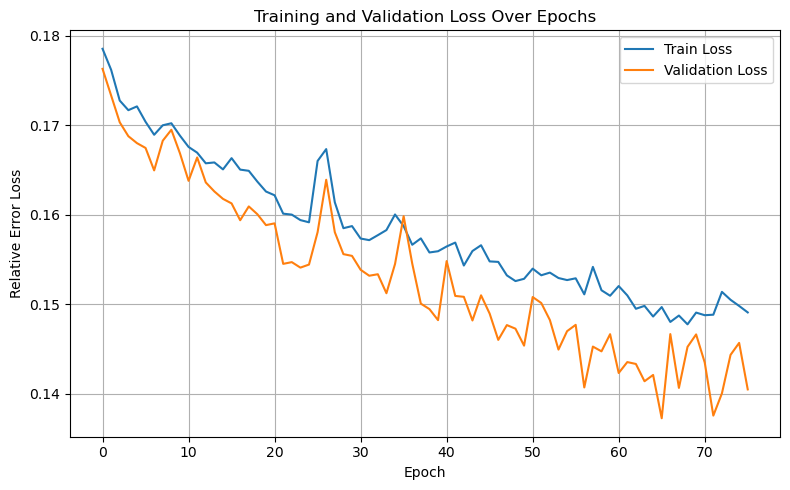

 Training metrics saved


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Augmentation Function --------------------
def apply_symmetry_augmentations(grid, scalar, label):
    """
    Applies horizontal, vertical, both flips to grid and label.
    Scalar remains unchanged. Returns list of (grid, scalar, label) tuples.
    """
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g = grid.copy()
        l = label.copy()
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)
        augmented.append((g, scalar, l))
    return augmented

# -------------------- Dataset Class --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, binary_grids, scalars, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.scalars = scalars.astype(np.float32).reshape(-1, 1, 1)
        self.flow_fields = flow_fields.astype(np.float32)
        self.scaled_grids = (self.binary_grids * self.scalars).astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)
        label_tensor = torch.tensor(self.flow_fields[idx])
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- Model Definition --------------------
class DeepUNet(nn.Module):
    def __init__(self):
        super(DeepUNet, self).__init__()
        # Encoder
        self.enc1 = self._conv_block(1, 16)
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = self._conv_block(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = self._conv_block(32, 64)
        self.pool3 = nn.MaxPool2d(2)
        
        self.enc4 = self._conv_block(64, 128)
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = self._conv_block(128, 256)
        
        # Decoder with skip connections
        self.up4 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec4 = self._conv_block(256, 128) 
        
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = self._conv_block(128, 64)  
        
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = self._conv_block(64, 32)  
        
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = self._conv_block(32, 16)  
        
        self.final = nn.Conv2d(16, 1, 1)
        
    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), 
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        
    def forward(self, x):
        binary_mask = (x > 0).float()
        
        # Encoder path
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.enc3(self.pool2(x2))
        x4 = self.enc4(self.pool3(x3))
        
        # Bottleneck
        x = self.bottleneck(self.pool4(x4))
        
        # Decoder path with skip connections
        x = self.up4(x)
        x = self.dec4(torch.cat([x, x4], dim=1))
        
        x = self.up3(x)
        x = self.dec3(torch.cat([x, x3], dim=1))
        
        x = self.up2(x)
        x = self.dec2(torch.cat([x, x2], dim=1))
        
        x = self.up1(x)
        x = self.dec1(torch.cat([x, x1], dim=1))
        
        # Final convolution and apply mask
        x = self.final(x)
        
        # zero flow at impermeable pixels
        return x.squeeze(1) * binary_mask.squeeze(1)




# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_unet_homogen_kaggle_aim.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    # Plot loss
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_kaggle_aim.png")
    plt.show()


    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_kaggle_aim.csv", index=False)
    print(" Training metrics saved")

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading + Training --------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'


binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")


augmented_grids = []
augmented_scalars = []
augmented_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]
    scalar = (params_df['delta_p'].iloc[i] * params_df['delta_A'].iloc[i]) / (
              params_df['visc'].iloc[i] * params_df['L'].iloc[i])
    
    augmented = apply_symmetry_augmentations(grid, scalar, label)
    for g, s, l in augmented:
        augmented_grids.append(g)
        augmented_scalars.append(s)
        augmented_labels.append(l)


binary_grids = np.array(augmented_grids)
scalars = np.array(augmented_scalars).reshape(-1, 1, 1)
flow_fields = np.array(augmented_labels)

dataset = ScaledGridDataset(binary_grids, scalars, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(42)

# Train
model = DeepUNet()
trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=1000, lr=3e-4, device=device)

# A masked u-net - USED FOR KAGGLE!

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 13
Layer-wise parameter count:
unet.enc1.0.weight             | 72
unet.enc1.0.bias               | 8
unet.enc1.2.weight             | 576
unet.enc1.2.bias               | 8
unet.enc2.0.weight             | 1152
unet.enc2.0.bias               | 16
unet.enc2.2.weight             | 2304
unet.enc2.2.bias               | 16
unet.bottleneck.0.weight       | 4608
unet.bottleneck.0.bias         | 32
unet.bottleneck.2.weight       | 9216
unet.bottleneck.2.bias         | 32
unet.up2.weight                | 2048
unet.up2.bias                  | 16
unet.dec2.0.weight             | 4608
unet.dec2.0.bias               | 16
unet.dec2.2.weight             | 2304
unet.dec2.2.bias               | 16
unet.up1.weight                | 512
unet.up1.bias                  | 8
unet.dec1.0.weight             | 1152
unet.dec1.0.bias               | 8
unet.dec1.2.weight             | 576
unet.dec1.2.bias               | 8
unet.final.weight              | 8
unet.final.bias                | 1

 

Epoch 1/1000: 100%|██████████| 169/169 [00:01<00:00, 101.02it/s]



Epoch 1 — Train Loss: 0.087817
Epoch 1 — Val Loss: 0.083325


Epoch 2/1000: 100%|██████████| 169/169 [00:01<00:00, 123.35it/s]


...


Epoch 9 — Train Loss: 0.087917
Epoch 9 — Val Loss: 0.083326


Epoch 10/1000: 100%|██████████| 169/169 [00:01<00:00, 126.12it/s]



Epoch 10 — Train Loss: 0.087884
Epoch 10 — Val Loss: 0.083326


Epoch 11/1000: 100%|██████████| 169/169 [00:01<00:00, 124.21it/s]



Epoch 11 — Train Loss: 0.087819
Epoch 11 — Val Loss: 0.083327
Early stopping triggered.
Training complete.


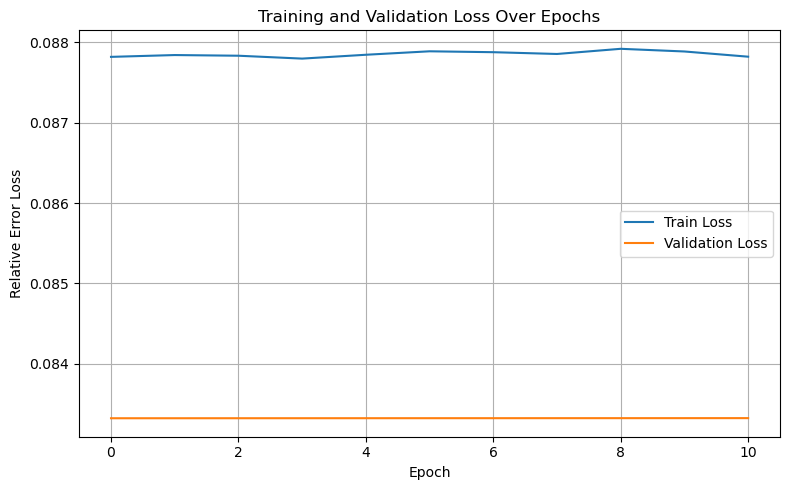

 Training metrics saved


In [ ]:


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Augmentation Function --------------------
def apply_symmetry_augmentations(grid, scalar, label):
    """
    Applies horizontal, vertical, both flips to grid and label.
    Scalar remains unchanged. Returns list of (grid, scalar, label) tuples.
    """
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g = grid.copy()
        l = label.copy()
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)
        augmented.append((g, scalar, l))
    return augmented

# -------------------- Dataset Class --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, binary_grids, scalars, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.scalars = scalars.astype(np.float32).reshape(-1, 1, 1)
        self.flow_fields = flow_fields.astype(np.float32)
        self.scaled_grids = (self.binary_grids * self.scalars).astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)
        label_tensor = torch.tensor(self.flow_fields[idx])
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- Model Definition --------------------
class TinyUNetHomogeneous(nn.Module):
    def __init__(self):
        super(TinyUNetHomogeneous, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(16, 8, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )

        self.final = nn.Conv2d(8, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.bottleneck(self.pool2(x2))
        x = self.up2(x3)
        x = self.dec2(torch.cat([x, x2], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, x1], dim=1))
        return self.final(x).squeeze(1)

# -------------------- Symmetry, GroupAverage, Masking --------------------
class ApplySymmetry(nn.Module):
    def forward(self, x):
        return torch.stack([
            x,
            x.flip(-1),        # horizontal flip
            x.flip(-2),        # vertical flip
            x.flip(-1, -2)     # both flips
        ], dim=1)  

class GroupAverage(nn.Module):
    def forward(self, x):
        return torch.mean(x, dim=1)  

class ImageMask(nn.Module):
    def forward(self, flow_prediction, input_image):
        return torch.abs(flow_prediction * input_image)  

class UNet_GA(nn.Module):
    def __init__(self, base_unet):
        super().__init__()
        self.apply_symmetry = ApplySymmetry()
        self.unet = base_unet
        self.group_average = GroupAverage()
        self.image_mask = ImageMask()

    def forward(self, x):
        binary_image = x 
        x = self.apply_symmetry(x)  
        B, N, C, H, W = x.shape
        x = x.view(B * N, C, H, W) 
        x = self.unet(x)            # run through U-Net
        x = x.view(B, N, H, W)      # un-merge
        x = self.group_average(x)  # average across symmetry outputs
        return self.image_mask(x, binary_image.squeeze(1))  # final masked output




# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10


    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_unet_homogen_aug_4_longer_GA_NEW_2.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")


    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_unet_aug_4_longer_GA_NEW_2.png")
    plt.show()

    # Save metrics to CSV
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_unet_aug_4_longer_GA_NEW_2.csv", index=False)
    print(" Training metrics saved")

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading + Training --------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

augmented_grids = []
augmented_scalars = []
augmented_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]
    scalar = (params_df['delta_p'].iloc[i] * params_df['delta_A'].iloc[i]) / (
              params_df['visc'].iloc[i] * params_df['L'].iloc[i])
    
    augmented = apply_symmetry_augmentations(grid, scalar, label)
    for g, s, l in augmented:
        augmented_grids.append(g)
        augmented_scalars.append(s)
        augmented_labels.append(l)


binary_grids = np.array(augmented_grids)
scalars = np.array(augmented_scalars).reshape(-1, 1, 1)
flow_fields = np.array(augmented_labels)


dataset = ScaledGridDataset(binary_grids, scalars, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(13)

# Train
base_unet = TinyUNetHomogeneous()
model = UNet_GA(base_unet)

trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=1000, lr=3e-4, device=device)

## YET ANOTHER MODEL LIKE THIS MASKED ONE 

C:\Users\asens\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Random seed set to 13
Layer-wise parameter count:
unet.enc1.0.weight             | 72
unet.enc1.0.bias               | 8
unet.enc1.2.weight             | 576
unet.enc1.2.bias               | 8
unet.enc2.0.weight             | 1152
unet.enc2.0.bias               | 16
unet.enc2.2.weight             | 2304
unet.enc2.2.bias               | 16
unet.bottleneck.0.weight       | 4608
unet.bottleneck.0.bias         | 32
unet.bottleneck.2.weight       | 9216
unet.bottleneck.2.bias         | 32
unet.up2.weight                | 2048
unet.up2.bias                  | 16
unet.dec2.0.weight             | 4608
unet.dec2.0.bias               | 16
unet.dec2.2.weight             | 2304
unet.dec2.2.bias               | 16
unet.up1.weight                | 512
unet.up1.bias                  | 8
unet.dec1.0.weight             | 1152
unet.dec1.0.bias               | 8
unet.dec1.2.weight             | 576
unet.dec1.2.bias               | 8
unet.final.weight              | 8
unet.final.bias                | 1

 

Epoch 1/1000: 100%|██████████| 169/169 [00:01<00:00, 102.41it/s]



Epoch 1 — Train Loss: 82287.038349
Epoch 1 — Val Loss: 0.270290


Epoch 2/1000: 100%|██████████| 169/169 [00:01<00:00, 122.64it/s]


...


Epoch 11 — Train Loss: 21338.753085
Epoch 11 — Val Loss: 0.192431


Epoch 12/1000: 100%|██████████| 169/169 [00:01<00:00, 113.64it/s]



Epoch 12 — Train Loss: 19772.248297
Epoch 12 — Val Loss: 0.201271


Epoch 13/1000: 100%|██████████| 169/169 [00:01<00:00, 113.83it/s]



Epoch 13 — Train Loss: 19697.981175
Epoch 13 — Val Loss: 0.207008
Early stopping triggered.
Training complete.


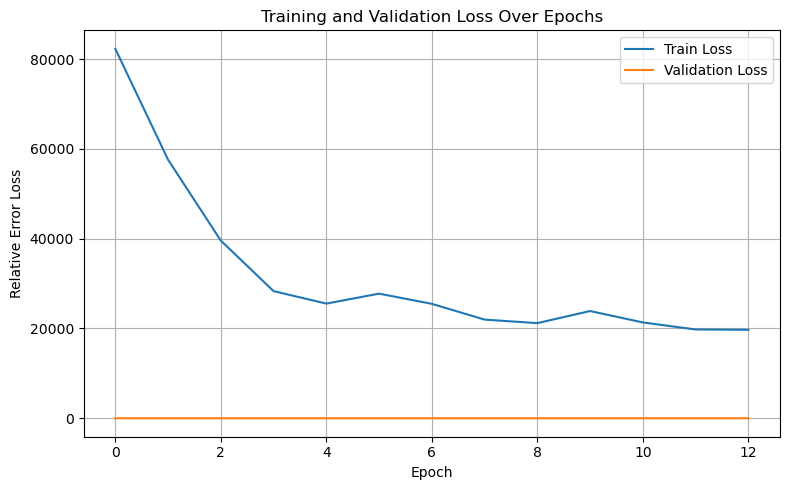

 Training metrics saved


In [67]:
# -------------------- Imports --------------------
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # for multi-GPU
        cudnn.deterministic = True
        cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# -------------------- Augmentation Function --------------------
def apply_symmetry_augmentations(grid, scalar, label):
    """
    Applies horizontal, vertical, both flips to grid and label.
    Scalar remains unchanged. Returns list of (grid, scalar, label) tuples.
    """
    augmented = []
    for flip in [None, 'h', 'v', 'hv']:
        g = grid.copy()
        l = label.copy()
        if flip == 'h':
            g = np.flip(g, axis=1)
            l = np.flip(l, axis=1)
        elif flip == 'v':
            g = np.flip(g, axis=0)
            l = np.flip(l, axis=0)
        elif flip == 'hv':
            g = np.flip(np.flip(g, axis=0), axis=1)
            l = np.flip(np.flip(l, axis=0), axis=1)
        augmented.append((g, scalar, l))
    return augmented

# -------------------- Dataset Class --------------------
class ScaledGridDataset(Dataset):
    def __init__(self, binary_grids, scalars, flow_fields, transform=None):
        self.binary_grids = binary_grids.astype(np.float32)
        self.scalars = scalars.astype(np.float32).reshape(-1, 1, 1)
        self.flow_fields = flow_fields.astype(np.float32)
        self.scaled_grids = (self.binary_grids * self.scalars).astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.scaled_grids)

    def __getitem__(self, idx):
        grid_tensor = torch.tensor(self.scaled_grids[idx]).unsqueeze(0)
        label_tensor = torch.tensor(self.flow_fields[idx])
        if self.transform:
            grid_tensor = self.transform(grid_tensor)
        return grid_tensor, label_tensor

# -------------------- Model Definition --------------------
class TinyUNetHomogeneous(nn.Module):
    def __init__(self):
        super(TinyUNetHomogeneous, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(16, 8, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
        )

        self.final = nn.Conv2d(8, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.bottleneck(self.pool2(x2))
        x = self.up2(x3)
        x = self.dec2(torch.cat([x, x2], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, x1], dim=1))
        return self.final(x).squeeze(1)

# -------------------- Symmetry, GroupAverage, Masking --------------------
class ApplySymmetry(nn.Module):
    def forward(self, x):
        return torch.stack([
            x,
            x.flip(-1),        # horizontal flip
            x.flip(-2),        # vertical flip
            x.flip(-1, -2)     # both flips
        ], dim=1)  # [B, 4, 1, H, W]

class GroupAverage(nn.Module):
    def forward(self, x):
        return torch.mean(x, dim=1)  # [B, H, W]

class ImageMask(nn.Module):
    def forward(self, flow_prediction, input_image):
        return torch.abs(flow_prediction * input_image)  # [B, H, W]

class UNet_GA(nn.Module):
    def __init__(self, base_unet):
        super().__init__()
        self.apply_symmetry = ApplySymmetry()
        self.unet = base_unet
        self.group_average = GroupAverage()
        self.image_mask = ImageMask()

    def forward(self, x):
        binary_image = x  # preserve original binary input for masking
        x = self.apply_symmetry(x)  # [B, 4, 1, H, W]
        B, N, C, H, W = x.shape
        x = x.view(B * N, C, H, W)  # merge symmetry group into batch
        x = self.unet(x)            # run through U-Net
        x = x.view(B, N, H, W)      # un-merge
        x = self.group_average(x)  # average across symmetry outputs
        return self.image_mask(x, binary_image.squeeze(1))  # final masked output




# -------------------- Loss Function --------------------
class RelativeErrorLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(RelativeErrorLoss, self).__init__()
        self.eps = eps

    def forward(self, predictions, targets):
        numerator = torch.abs(targets - predictions)
        denominator = targets + self.eps
        relative_error = numerator / denominator
        return relative_error.mean()

# -------------------- Evaluation Function --------------------
def evaluate_model(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for grid_batch, target_batch in data_loader:
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_loader=None, num_epochs=20, lr=1e-3, device='cuda'):
    model = model.to(device)
    count_parameters(model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    criterion = RelativeErrorLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 10

    # Track loss values
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for grid_batch, target_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            grid_batch = grid_batch.to(device)
            target_batch = target_batch.to(device)

            predictions = model(grid_batch)
            loss = criterion(predictions, target_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.6f}")

        if val_loader:
            val_loss = evaluate_model(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            print(f"Epoch {epoch+1} — Val Loss: {val_loss:.6f}")
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_unet_homogen_aug_4_longer_GA_NEW_3.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= early_stop_patience:
                print("Early stopping triggered.")
                break

    print("Training complete.")

    # Plot loss
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    if val_loader:
        plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Relative Error Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_curve_unet_aug_4_longer_GA_NEW_3.png")
    plt.show()

    # Save metrics to CSV
    metrics_df = pd.DataFrame({
        'epoch': list(range(1, len(train_losses)+1)),
        'train_loss': train_losses,
        'val_loss': val_losses if val_loader else [None]*len(train_losses)
    })
    metrics_df.to_csv("training_metrics_unet_aug_4_longer_GA_NEW_3.csv", index=False)
    print(" Training metrics saved")

    return model

def count_parameters(model):
    total_params = 0
    print("Layer-wise parameter count:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:30} | {num_params}")
    print(f"\n Total trainable parameters: {total_params:,}")
    return total_params

# -------------------- Data Loading + Training --------------------
# Device selection
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load raw data
binary_grids_raw = np.load("train_inputs.npy")
flow_fields_raw = np.load("train_labels.npy")
params_df = pd.read_csv("train_params.csv")

# Apply augmentations
augmented_grids = []
augmented_scalars = []
augmented_labels = []

for i in range(len(binary_grids_raw)):
    grid = binary_grids_raw[i]
    label = flow_fields_raw[i]
    scalar = (params_df['delta_p'].iloc[i] * params_df['delta_A'].iloc[i]) / (
              params_df['visc'].iloc[i] * params_df['L'].iloc[i])
    
    augmented = apply_symmetry_augmentations(grid, scalar, label)
    for g, s, l in augmented:
        augmented_grids.append(g)
        augmented_scalars.append(s)
        augmented_labels.append(l)

# Convert to arrays
binary_grids = np.array(augmented_grids)
scalars = np.array(augmented_scalars).reshape(-1, 1, 1)
flow_fields = np.array(augmented_labels)

# Dataset and split
dataset = ScaledGridDataset(binary_grids, scalars, flow_fields)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

set_seed(13)

# Train
base_unet = TinyUNetHomogeneous()
model = UNet_GA(base_unet)

trained_model = train_model(model, train_loader, val_loader=val_loader, num_epochs=1000, lr=1e-8, device=device)